# Antibody Developability Optimization — Pipeline

Generates novel HCDR3 variants of therapeutic antibodies with better predicted
developability (HIC and AC-SINS) using conditional flow matching in AbLang2
CDR3 embedding space.

**Run order:** Execute every section top-to-bottom. Sections 2 and 4 are slow
(~15 min each on T4) but cache results to Drive so they only run once.

### Architecture summary
| Component | What it does |
|---|---|
| AbLang2 (frozen) | Extracts CDR3, framework, and full-sequence embeddings |
| Ridge oracle | Predicts HIC and AC-SINS from full-sequence embeddings |
| Flow model | Generates candidate CDR3 embedding targets per parent framework |
| AbLang2 masked pass | Produces natural CDR3 sequences for the parent framework |
| Distance matrix | Selects sequences whose embeddings are closest to flow targets |
| Oracle (Phase 3) | Scores final assembled sequences — never intermediate ODE states |

> Runtime → Change runtime type → **T4 GPU** before running.

---
## Section 0 — Installs & Imports

In [1]:
# Install required packages.
# Run this cell once. If Colab prompts to restart the runtime, do so
# and then skip back to this cell (it will already be installed).
!pip install -q ablang2        # AbLang2 antibody language model
!pip install -q torchcfm       # Conditional flow matching training loop
!pip install -q torchdiffeq    # ODE integrator for Phase 1 sampling
!pip install -q scikit-learn scipy matplotlib seaborn joblib

In [2]:
import os, re, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, ttest_rel, ks_2samp
from scipy.spatial.distance import cdist as scipy_cdist
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold
import joblib

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher
from torchdiffeq import odeint

# For LoRA fine-tuning (optional)
from peft import LoraConfig, TaskType, get_peft_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Directory and file paths ──────────────────────────────────────────────────
# All cached numpy arrays, model checkpoints, and eval inputs are saved here.
# If you move the project, update PROJECT_DIR and everything else follows.
PROJECT_DIR = '/content/drive/MyDrive/project'
EVAL_DIR    = f'{PROJECT_DIR}/eval_inputs_oas_pretrain'   # saved artifacts for eval notebook
DATA_PATH   = f'{PROJECT_DIR}/GDPa1_v1.2_20250814.csv'

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,    exist_ok=True)

# Convenience function so cached file paths are always consistent
CACHE = lambda name: f'{PROJECT_DIR}/{name}'

# ── OAS Pretraining Paths & Hyperparameters ───────────────────────────────────
OAS_DIR             = f'{PROJECT_DIR}/oas_paired'       # folder with downloaded .csv.gz
OAS_CACHE_DIR       = f'{PROJECT_DIR}/oas_cache'        # cached embeddings
OAS_PRETRAIN_EPOCHS = 5          # pretraining epochs on OAS
OAS_PRETRAIN_BS     = 256        # batch size for OAS flow training
OAS_PRETRAIN_LR     = 1e-3       # learning rate for OAS pretraining
OAS_FINETUNE_LR     = 1e-4       # learning rate for GDPa1 fine-tuning
OAS_MAX_SEQUENCES   = 2_000_000  # cap on OAS sequences after filtering
OAS_EMBED_BATCH     = 16         # AbLang2 batch size for OAS embedding

os.makedirs(OAS_DIR,       exist_ok=True)
os.makedirs(OAS_CACHE_DIR, exist_ok=True)

# ── Dataset column names ──────────────────────────────────────────────────────
# Defined once here so renaming a column only requires one edit.
COL_VH    = 'vh_protein_sequence'
COL_VL    = 'vl_protein_sequence'
COL_HIC   = 'HIC'
COL_SINS  = 'AC-SINS_pH7.4'
COL_FOLD  = 'hierarchical_cluster_fold'
COL_AHO_H = 'heavy_aligned_aho'
COL_AHO_L = 'light_aligned_aho'
COL_NAME  = 'antibody_name'

# ── Key hyperparameters ───────────────────────────────────────────────────────
TEST_FOLD       = 1      # fold held out as test set (never used during training)
N_FLOW_SAMPLES  = 50     # independent noise seeds per test antibody in Phase 1
N_ODE_STEPS     = 100    # Euler integration steps for ODE
M_SEQUENCES     = 20     # sequences sampled from AbLang2 masked pass in Phase 2
TEMPERATURE     = 1.0    # sampling temperature for AbLang2 (1.0 = raw distribution)
TOP_K_SELECT    = 5      # top-k (flow_target, sequence) pairs passed to oracle
FLOW_EPOCHS     = 1000   # training epochs for flow model
CURRENT_SIGMA   = 0.5    # CFM noise parameter (higher = less deterministic)
PLS_COMPONENTS  = 10     # PLS dimensionality for flow model input space
AA_VOCAB        = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX       = {aa: i for i, aa in enumerate(AA_VOCAB)}
ABLANG_MASK     = '*'    # AbLang2's mask token character

Mounted at /content/drive


---
## Section 1 — Data Loading, CDR3 Extraction & Split

### 1a — Load dataset

In [4]:
df = pd.read_csv(DATA_PATH)
print(f'Raw rows: {df.shape[0]}')

# Drop antibodies missing either chain sequence — we need both for AbLang2
df = df.dropna(subset=[COL_VH, COL_VL]).reset_index(drop=True)
print(f'After dropping missing VH/VL: {len(df)}')

print('\nPrimary oracle target missingness (will be imputed with training median):')
print(df[[COL_HIC, COL_SINS]].isna().sum())

Raw rows: 246
After dropping missing VH/VL: 246

Primary oracle target missingness (will be imputed with training median):
HIC              4
AC-SINS_pH7.4    4
dtype: int64


### 1b — HCDR3 extraction via AHo numbering

AHo CDR-H3 occupies positions 107–138 (1-indexed) = indices 106–137 (0-indexed).
The `heavy_aligned_aho` column contains the VH sequence aligned to AHo, with
dashes (`-`) for positions this antibody does not have a residue at.

We walk the aligned string and record which positions in the **ungapped** raw VH
sequence fall inside CDR3 vs framework. These integer index lists are reused
later to: (1) extract sub-embeddings, (2) place AbLang2 mask tokens, (3) splice
generated CDR3 sequences back into the parent framework.

In [5]:
AHO_CDR3_START = 106   # 0-indexed inclusive
AHO_CDR3_END   = 138   # 0-indexed exclusive (positions 106..137)

def get_cdr3_and_fw_indices(aligned_aho_seq):
    """
    Parse an AHo-aligned VH string and return two lists of integer indices
    into the UNGAPPED raw VH sequence.

    cdr3_idx : positions inside AHo CDR-H3 window (106-137)
    fw_idx   : all other positions (framework regions FR1-FR4)

    How it works: walk character by character through the aligned string.
    A dash means no residue at this AHo position for this antibody — skip it.
    Any real amino acid increments the raw-position counter and gets bucketed
    into CDR3 or framework based on its AHo position.
    """
    cdr3_idx, fw_idx = [], []
    raw_pos = 0
    for aho_pos, char in enumerate(aligned_aho_seq):
        if char == '-':
            continue
        if AHO_CDR3_START <= aho_pos < AHO_CDR3_END:
            cdr3_idx.append(raw_pos)
        else:
            fw_idx.append(raw_pos)
        raw_pos += 1
    return cdr3_idx, fw_idx

# Extract CDR3 sequences and index lists for all antibodies
hcdr3_seqs, h_cdr3_idx_list, h_fw_idx_list = [], [], []
for _, row in df.iterrows():
    if pd.isna(row[COL_AHO_H]):
        hcdr3_seqs.append(None)
        h_cdr3_idx_list.append([])
        h_fw_idx_list.append([])
        continue
    cdr3_idx, fw_idx = get_cdr3_and_fw_indices(row[COL_AHO_H])
    seq = ''.join(row[COL_VH][i] for i in cdr3_idx if i < len(row[COL_VH]))
    hcdr3_seqs.append(seq if seq else None)
    h_cdr3_idx_list.append(cdr3_idx)
    h_fw_idx_list.append(fw_idx)

df['hcdr3_sequence'] = hcdr3_seqs
df['h_cdr3_idx']     = h_cdr3_idx_list
df['h_fw_idx']       = h_fw_idx_list
df['hcdr3_len']      = df['hcdr3_sequence'].apply(
    lambda s: len(s) if isinstance(s, str) else 0)

valid = df['hcdr3_sequence'].notna() & (df['hcdr3_sequence'] != '')
print(f'Antibodies with valid HCDR3: {valid.sum()} / {len(df)}')
print(df.loc[valid, 'hcdr3_len'].describe().round(1))

Antibodies with valid HCDR3: 246 / 246
count    246.0
mean      12.5
std        3.2
min        5.0
25%       10.0
50%       12.0
75%       14.0
max       23.0
Name: hcdr3_len, dtype: float64


### 1c — Train/test split and CDR3 length analysis

Train (folds 2-5): 196  |  Test (fold 1): 50
CDR3 length KS test: stat=0.050  p=1.000
✓ compatible

CDR3 length distribution:
 length  train  test  train_%  test_%
      5      3     0      1.5     0.0
      6      4     0      2.0     0.0
      7      1     1      0.5     2.0
      8      8     3      4.1     6.0
      9     17     5      8.7    10.0
     10     17     5      8.7    10.0
     11     22     6     11.2    12.0
     12     35     6     17.9    12.0
     13     23     7     11.7    14.0
     14     21     8     10.7    16.0
     15     14     3      7.1     6.0
     16     10     3      5.1     6.0
     17      4     0      2.0     0.0
     18      7     1      3.6     2.0
     19      6     1      3.1     2.0
     20      1     1      0.5     2.0
     22      1     0      0.5     0.0
     23      2     0      1.0     0.0


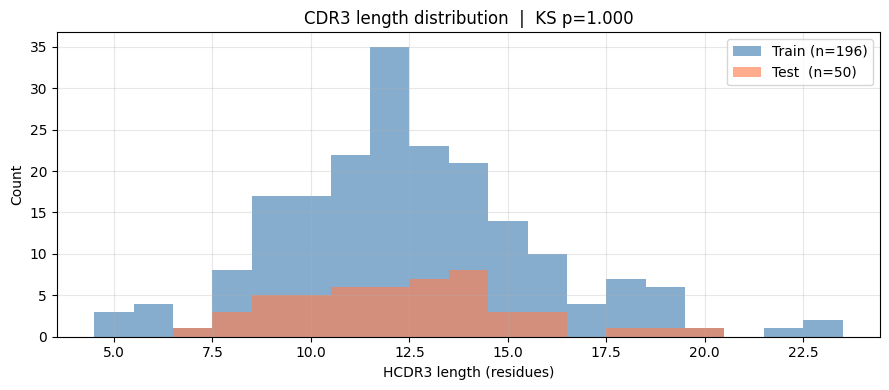

In [6]:
# Split using pre-computed hierarchical cluster folds.
# Fold 1 = test (~49 antibodies), folds 2-5 = train (~197 antibodies).
# The clustering ensures antibodies with similar sequences land in the same fold,
# so holding out fold 1 prevents the model from memorising the training sequences.
train_mask = df[COL_FOLD] != TEST_FOLD
test_mask  = df[COL_FOLD] == TEST_FOLD
train_idx  = df.index[train_mask].values
test_idx   = df.index[test_mask].values
print(f'Train (folds 2-5): {len(train_idx)}  |  Test (fold 1): {len(test_idx)}')

# ── CDR3 length distribution ──────────────────────────────────────────────────
# Important: Phase 2 places exactly len(parent_CDR3) mask tokens, so generated
# sequences are guaranteed the same length as the parent. Knowing the length
# distribution tells us whether the train/test split is balanced in this respect.
train_lens = df.loc[train_idx, 'hcdr3_len'].values
test_lens  = df.loc[test_idx,  'hcdr3_len'].values
train_lens = train_lens[train_lens > 0]
test_lens  = test_lens[test_lens > 0]

ks_stat, ks_p = ks_2samp(train_lens, test_lens)
print(f'CDR3 length KS test: stat={ks_stat:.3f}  p={ks_p:.3f}')
print('✓ compatible' if ks_p >= 0.05 else '⚠ distributions differ')

# Per-length count table
all_lens   = sorted(set(train_lens) | set(test_lens))
len_table  = pd.DataFrame({
    'length':   all_lens,
    'train':    [(train_lens == l).sum() for l in all_lens],
    'test':     [(test_lens  == l).sum() for l in all_lens],
})
len_table['train_%'] = (len_table['train'] / len(train_lens) * 100).round(1)
len_table['test_%']  = (len_table['test']  / len(test_lens)  * 100).round(1)
print('\nCDR3 length distribution:')
print(len_table[len_table[['train','test']].sum(axis=1) > 0].to_string(index=False))

# Histogram comparing train vs test length distributions
bins = np.arange(min(all_lens) - 0.5, max(all_lens) + 1.5, 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_lens, bins=bins, alpha=0.65, color='steelblue',
        label=f'Train (n={len(train_lens)})')
ax.hist(test_lens,  bins=bins, alpha=0.65, color='coral',
        label=f'Test  (n={len(test_lens)})')
ax.set(xlabel='HCDR3 length (residues)', ylabel='Count',
       title=f'CDR3 length distribution  |  KS p={ks_p:.3f}')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CACHE('cdr3_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 1d — Chemical liability annotation

In [7]:
# Scan each HCDR3 for chemical degradation motifs.
# NG = deamidation, DG/DS = isomerization, NxS/NxT = N-linked glycosylation.
# These motifs are engineering liabilities in therapeutic antibodies.
# We report Spearman correlation with assay values to verify they encode
# developability signal in this dataset.
LIABILITY_PATTERNS = {
    'NG':  re.compile(r'NG'),
    'DG':  re.compile(r'DG'),
    'DS':  re.compile(r'DS'),
    'NxS': re.compile(r'N[^P]S'),
    'NxT': re.compile(r'N[^P]T'),
}

def count_liabilities(seq):
    if not isinstance(seq, str) or not seq:
        return 0, {}
    counts = {n: len(p.findall(seq)) for n, p in LIABILITY_PATTERNS.items()}
    return sum(counts.values()), counts

total_liabs, liab_details = zip(*[count_liabilities(s) for s in df['hcdr3_sequence']])
df['liability_count']  = total_liabs
df['liability_detail'] = liab_details

print('Liability count distribution:')
print(df['liability_count'].value_counts().sort_index())
for col in [COL_HIC, COL_SINS]:
    sub = df[[col, 'liability_count']].dropna()
    rho, p_val = spearmanr(sub['liability_count'], sub[col])
    print(f'Spearman ρ(liability_count, {col}): {rho:+.3f}  p={p_val:.3f}')

Liability count distribution:
liability_count
0    198
1     46
2      2
Name: count, dtype: int64
Spearman ρ(liability_count, HIC): +0.069  p=0.284
Spearman ρ(liability_count, AC-SINS_pH7.4): -0.089  p=0.166


### 1e — HIC/AC-SINS imputation and distribution check

In [8]:
# Impute the ~3 missing HIC and AC-SINS values using the TRAINING-SET median.
# Computing the median on the full dataset would leak fold-1 statistics
# into the normalization. We compute on folds 2-5 only and apply everywhere.
def impute_train_median(df, col, train_idx):
    vals   = df[col].copy().astype(float)
    median = float(np.nanmedian(vals.values[train_idx]))
    return vals.fillna(median).values, median

y_hic,  hic_med  = impute_train_median(df, COL_HIC,  train_idx)
y_sins, sins_med = impute_train_median(df, COL_SINS, train_idx)

y_hic_train,  y_hic_test  = y_hic[train_idx],  y_hic[test_idx]
y_sins_train, y_sins_test = y_sins[train_idx], y_sins[test_idx]

print(f'HIC  imputation median: {hic_med:.3f}')
print(f'SINS imputation median: {sins_med:.3f}')

# KS test: verify fold 1 distribution is not drastically different from training.
# If p < 0.05 consider using fold 2 as the test set instead.
for col, ytr, yte in [(COL_HIC, y_hic_train, y_hic_test),
                       (COL_SINS, y_sins_train, y_sins_test)]:
    s, p_val = ks_2samp(ytr, yte)
    flag = '✓' if p_val >= 0.05 else '⚠ consider fold 2'
    print(f'KS {col}: stat={s:.3f}  p={p_val:.3f}  {flag}')

HIC  imputation median: 2.735
SINS imputation median: 1.625
KS HIC: stat=0.137  p=0.400  ✓
KS AC-SINS_pH7.4: stat=0.092  p=0.853  ✓


---
## Section 2 — AbLang2 Embedding Extraction

Three embeddings are computed per antibody from the **frozen** AbLang2 model:

| Embedding | AbLang2 mode | Used for |
|---|---|---|
| `cdr3_embs` | rescoding, mean-pool CDR3 positions | Flow model target distribution |
| `fw_embs` | rescoding with CDR3 **masked to `*`** first | Flow model conditioning |
| `full_embs` | seqcoding (mean-pool full VH+VL) | Oracle training and scoring |

**Why mask the CDR3 before computing the framework embedding?**
AbLang2 is a transformer — every position attends to every other position.
Without masking, the framework hidden states encode CDR3 information via attention.
At inference, a conditioning signal that leaks CDR3 information would let the
flow model reconstruct the original CDR3 rather than generate a novel one.
Replacing CDR3 positions with `*` before the forward pass eliminates this leak.

In [9]:
import ablang2

print('Loading AbLang2 paired model (frozen)...')
ablang = ablang2.pretrained(model_to_use='ablang2-paired',
                            random_init=False, ncpu=1, device=DEVICE)
ablang.freeze()  # never fine-tune — only 197 training points
print('AbLang2 loaded.')

Loading AbLang2 paired model (frozen)...
AbLang2 loaded.


### 2a — CDR3 embeddings

In [10]:
# Mean-pool the AbLang2 hidden states at CDR3 positions only.
# These are the TARGETS for flow model training — the model learns to
# map Gaussian noise toward this distribution of CDR3 embeddings.
CDR3_CACHE = CACHE('cdr3_embeddings.npy')

if os.path.exists(CDR3_CACHE):
    cdr3_embs = np.load(CDR3_CACHE)
    print(f'Loaded CDR3 embeddings from cache: {cdr3_embs.shape}')
else:
    print('Computing CDR3 embeddings (run once, ~10 min on T4)...')
    BATCH, cdr3_list = 8, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        seqs = list(zip(rows[COL_VH], rows[COL_VL]))
        with torch.no_grad():
            reps = ablang(seqs, mode='rescoding')  # per-residue hidden states
        for j, row in enumerate(rows.itertuples()):
            hidden = np.array(reps[j])
            vh_len = len(row.vh_protein_sequence)
            h_hid  = hidden[:vh_len]  # VH portion only
            valid  = [k for k in row.h_cdr3_idx if k < len(h_hid)]
            cdr3_list.append(h_hid[valid].mean(0) if valid else np.zeros(480))
        if i % 40 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    cdr3_embs = np.vstack(cdr3_list)
    np.save(CDR3_CACHE, cdr3_embs)
    print(f'Saved: {cdr3_embs.shape}')

CDR3_DIM = cdr3_embs.shape[1]  # 480

Loaded CDR3 embeddings from cache: (246, 480)


### 2b — Masked framework embeddings

In [11]:
FW_CACHE = CACHE('fw_masked_embeddings.npy')

def mask_cdr3(vh_seq, cdr3_idx):
    """Replace CDR3 positions with AbLang2 mask token before forward pass."""
    chars = list(vh_seq)
    for i in cdr3_idx:
        if i < len(chars): chars[i] = ABLANG_MASK
    return ''.join(chars)

if os.path.exists(FW_CACHE):
    fw_embs = np.load(FW_CACHE)
    print(f'Loaded FW embeddings from cache: {fw_embs.shape}')
else:
    print('Computing masked-framework embeddings...')
    BATCH, fw_list = 8, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        # Mask CDR3 residues in each VH before the forward pass
        masked_seqs = [(mask_cdr3(r.vh_protein_sequence, r.h_cdr3_idx),
                        r.vl_protein_sequence)
                       for r in rows.itertuples()]
        with torch.no_grad():
            reps = ablang(masked_seqs, mode='rescoding')
        for j, row in enumerate(rows.itertuples()):
            hidden = np.array(reps[j])
            vh_len = len(row.vh_protein_sequence)
            vl_len = len(row.vl_protein_sequence)
            n_ex   = hidden.shape[0] - vh_len - vl_len
            h_hid  = hidden[:vh_len]
            l_hid  = hidden[vh_len + n_ex:]
            # Framework = non-CDR3 VH positions + all VL positions
            fw_h = h_hid[row.h_fw_idx].mean(0) if row.h_fw_idx else np.zeros(480)
            vl_v = list(range(min(vl_len, l_hid.shape[0])))
            fw_l = l_hid[vl_v].mean(0) if vl_v else np.zeros(480)
            fw_list.append((fw_h + fw_l) / 2.0)
        if i % 40 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    fw_embs = np.vstack(fw_list)
    np.save(FW_CACHE, fw_embs)
    print(f'Saved: {fw_embs.shape}')

FW_DIM = fw_embs.shape[1]

Loaded FW embeddings from cache: (246, 480)


### 2c - Full-sequence embeddings (oracle input)

In [12]:
# seqcoding returns one 480d vector per antibody (mean-pool over full VH+VL).
# HIC and AC-SINS are whole-molecule properties — CDR3-only embeddings have
# weaker predictive power. The oracle needs the full sequence representation.
FULL_CACHE = CACHE('full_embeddings.npy')

if os.path.exists(FULL_CACHE):
    full_embs = np.load(FULL_CACHE)
    print(f'Loaded full embeddings from cache: {full_embs.shape}')
else:
    print('Computing full-sequence embeddings...')
    BATCH, full_list = 16, []
    for i in range(0, len(df), BATCH):
        rows = df.iloc[i:i+BATCH]
        seqs = list(zip(rows[COL_VH], rows[COL_VL]))
        with torch.no_grad():
            emb = ablang(seqs, mode='seqcoding')
        full_list.append(emb if isinstance(emb, np.ndarray)
                          else emb.cpu().numpy())
        if i % 64 == 0: print(f'  {min(i+BATCH, len(df))}/{len(df)}')
    full_embs = np.vstack(full_list)
    np.save(FULL_CACHE, full_embs)
    print(f'Saved: {full_embs.shape}')

FULL_DIM = full_embs.shape[1]
print(f'Dims — CDR3: {CDR3_DIM}, FW: {FW_DIM}, Full: {FULL_DIM}')

Loaded full embeddings from cache: (246, 480)
Dims — CDR3: 480, FW: 480, Full: 480


### 2d — Embedding space analysis

Three diagnostics that should be run before training:
1. **Intrinsic dimensionality**: how many PCA components explain 90% of CDR3 variance?
2. **Developability gradient**: do PC1–PC2 show HIC/AC-SINS structure? (usually no — developability directions are in higher PCs)
3. **Test set position**: do fold-1 antibodies fall inside the training distribution?

CDR3 embedding intrinsic dimensionality:
  9 PCs explain 50% variance
  51 PCs explain 90% variance
  (Full space = 480d — effective dim is much lower)


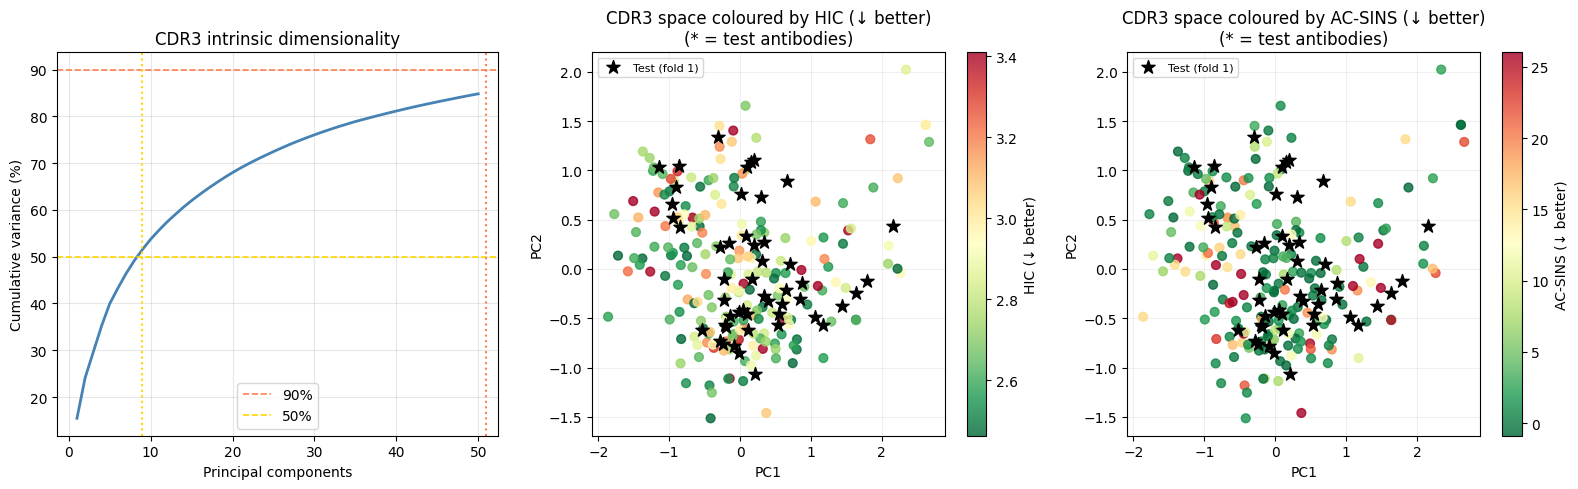

Within-train NN dist (95th pctile): 1.81
Test NN dist: mean=1.29  median=1.27  max=1.72
✓ All test antibodies within training distribution range


In [13]:
# Fit PCA on training CDR3 embeddings ONLY.
# Using all 246 would leak test-set variance into the PCA directions.
pca = PCA(n_components=50, random_state=42)
pca.fit(cdr3_embs[train_idx])

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90   = int(np.searchsorted(cumvar, 0.90)) + 1
n_50   = int(np.searchsorted(cumvar, 0.50)) + 1
print(f'CDR3 embedding intrinsic dimensionality:')
print(f'  {n_50} PCs explain 50% variance')
print(f'  {n_90} PCs explain 90% variance')
print(f'  (Full space = {CDR3_DIM}d — effective dim is much lower)')

pc_train = pca.transform(cdr3_embs[train_idx])
pc_test  = pca.transform(cdr3_embs[test_idx])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: cumulative explained variance
ax = axes[0]
ax.plot(range(1, 51), cumvar * 100, lw=2, color='steelblue')
ax.axhline(90, color='coral', ls='--', lw=1.2, label='90%')
ax.axhline(50, color='gold',  ls='--', lw=1.2, label='50%')
ax.axvline(n_90, color='coral', ls=':')
ax.axvline(n_50, color='gold',  ls=':')
ax.set(xlabel='Principal components', ylabel='Cumulative variance (%)',
       title='CDR3 intrinsic dimensionality')
ax.legend(); ax.grid(True, alpha=0.3)

# Plots 2-3: PC1 vs PC2 coloured by HIC and AC-SINS
for ax, (y_tr, label, cmap) in zip(axes[1:], [
        (y_hic_train,  'HIC (↓ better)',      'RdYlGn_r'),
        (y_sins_train, 'AC-SINS (↓ better)',  'RdYlGn_r')]):
    sc = ax.scatter(pc_train[:,0], pc_train[:,1], c=y_tr,
                    cmap=cmap, s=40, alpha=0.8, zorder=2,
                    vmin=np.percentile(y_tr,5), vmax=np.percentile(y_tr,95))
    ax.scatter(pc_test[:,0], pc_test[:,1], c='black',
               marker='*', s=100, label='Test (fold 1)', zorder=3)
    plt.colorbar(sc, ax=ax, label=label)
    ax.set(xlabel='PC1', ylabel='PC2',
           title=f'CDR3 space coloured by {label}\n(* = test antibodies)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(CACHE('embedding_space_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Test-set OOD check ────────────────────────────────────────────────────────
# Compute within-training nearest-neighbour distances (excluding self-pairs)
# to define a 'normal' inter-point gap. Flag test antibodies that are farther
# from any training point than the 95th percentile of that gap distribution.
train_pc20 = pc_train[:, :20]
test_pc20  = pc_test[:,  :20]

train_pw = scipy_cdist(train_pc20, train_pc20)
np.fill_diagonal(train_pw, np.inf)  # exclude self-distances
train_nn  = train_pw.min(axis=1)
threshold = np.percentile(train_nn, 95)

nn_dists = scipy_cdist(test_pc20, train_pc20).min(axis=1)
outliers = np.where(nn_dists > threshold)[0]

print(f'Within-train NN dist (95th pctile): {threshold:.2f}')
print(f'Test NN dist: mean={nn_dists.mean():.2f}  '
      f'median={np.median(nn_dists):.2f}  max={nn_dists.max():.2f}')
if len(outliers):
    print(f'OOD test antibodies: {len(outliers)}')
    for i in outliers:
        print(f'  {df.iloc[test_idx[i]][COL_NAME]}')
else:
    print('✓ All test antibodies within training distribution range')

---
## Section 2e — LoRA Encoder Classes

These classes enable optional LoRA fine-tuning of AbLang2 for improved oracle predictions.
Set `USE_LORA_ORACLE = True` in Section 3 to use the fine-tuned oracle instead of Ridge.

In [14]:
from torch.utils.data import Dataset, DataLoader

# LoRA hyperparameters (matching developability_model/ablang2_fine_tuned_GDPa1.ipynb)
LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1
HEAD_DROPOUT = 0.1
LORA_EPOCHS = 30
LORA_BATCH_SIZE = 8
LORA_LR = 1e-4
LORA_WEIGHT_DECAY = 1e-4


class AbLang2LoRAEncoder(nn.Module):
    """
    Wraps the AbLang2 AbRep encoder and injects LoRA adapters into every
    MultiHeadAttention block (q_proj, k_proj, v_proj, out_proj).
    Returns mean-pooled [B, hidden_size] embeddings ignoring padding tokens.
    """
    LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "out_proj"]

    def __init__(self, ablang2_model, lora_r=LORA_R, lora_alpha=LORA_ALPHA,
                 lora_dropout=LORA_DROPOUT, freeze_non_lora=True):
        super().__init__()
        self.ablang = ablang2_model
        self.tokenizer = ablang2_model.tokenizer
        self.padding_tkn = ablang2_model.AbLang.AbRep.padding_tkn

        lora_cfg = LoraConfig(
            r=lora_r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=self.LORA_TARGET_MODULES,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
        )
        self.ablang.AbLang = get_peft_model(self.ablang.AbLang, lora_cfg)

        if freeze_non_lora:
            for name, param in self.ablang.AbLang.named_parameters():
                if "lora_" not in name:
                    param.requires_grad_(False)

        n_trainable = sum(p.numel() for p in self.ablang.AbLang.parameters() if p.requires_grad)
        n_total = sum(p.numel() for p in self.ablang.AbLang.parameters())
        print(f"LoRA injected: {n_trainable:,} trainable / {n_total:,} total "
              f"({100 * n_trainable / n_total:.2f}%)")

    def tokenize(self, vh_seqs, vl_seqs, device):
        # For 'ablang2-paired', the tokenizer expects a list of (heavy_seq, light_seq) tuples
        paired_sequences = list(zip(vh_seqs, vl_seqs))
        tokens = self.tokenizer(paired_sequences, pad=True, w_extra_tkns=True)
        return tokens.to(device)

    def forward(self, tokens):
        self.ablang.AbLang.train()
        reps = self.ablang.AbLang.AbRep(tokens)
        hidden = reps.last_hidden_states
        pad_mask = tokens.eq(self.padding_tkn).unsqueeze(-1)
        hidden = hidden.masked_fill(pad_mask, 0.0)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).float()
        return hidden.sum(dim=1) / lengths


class RegressionHead(nn.Module):
    """Single-target regression head on top of pooled embeddings."""
    def __init__(self, hidden_size, dropout=HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, emb):
        return self.net(emb).squeeze(-1)


class AntibodyDataset(Dataset):
    def __init__(self, vh_seqs, vl_seqs, labels):
        super().__init__()
        self.vh = vh_seqs
        self.vl = vl_seqs
        self.labels = labels

    def __len__(self):
        return len(self.vh)

    def __getitem__(self, idx):
        return self.vh[idx], self.vl[idx], self.labels[idx]


def collate_fn(batch):
    vh, vl, labels = zip(*batch)
    return list(vh), list(vl), torch.tensor(labels, dtype=torch.float32)


@torch.no_grad()
def predict_lora(encoder, head, loader, device, target_label_type):
    encoder.ablang.AbLang.eval()
    head.eval()
    all_preds, all_labels = [], []
    for vh, vl, labels_hic, labels_sins in loader: # Unpack all four items
        tokens = encoder.tokenize(vh, vl, device)
        embedding = encoder(tokens)
        preds = head(embedding).cpu().numpy()
        all_preds.append(preds)

        if target_label_type == 'hic':
            all_labels.append(labels_hic.numpy())
        elif target_label_type == 'sins':
            all_labels.append(labels_sins.numpy())
        else:
            raise ValueError("Invalid target_label_type. Must be 'hic' or 'sins'.")

    return np.concatenate(all_preds), np.concatenate(all_labels)

def train_epoch_lora(encoder, head, loader, optimizer, loss_fn, device):
    encoder.ablang.AbLang.train()
    head.train()
    total_loss = 0.0
    for vh, vl, labels in loader:
        tokens = encoder.tokenize(vh, vl, device)
        labels = labels.to(device)
        optimizer.zero_grad()
        emb = encoder(tokens)
        preds = head(emb)
        loss = loss_fn(preds, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(head.parameters()), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
    return total_loss / len(loader.dataset)

---
## Section 3 — Oracle Training

Ridge regression predicts HIC and AC-SINS from AbLang2 full-sequence embeddings.
Trained on folds 2–5 only. Fold-1 labels are **never** used during training.

Ridge is appropriate here because:
- N=197 training points is small for a deep model
- The oracle is used for candidate **ranking** not absolute prediction
- It matches the Ginkgo Bioworks baseline (Zhao et al. 2025) for comparison

In [15]:
# Scalers must be fit on training data only.
# Fitting on all 246 antibodies would leak test-set mean/std into normalization.
full_scaler = StandardScaler()
X_full_tr   = full_scaler.fit_transform(full_embs[train_idx])
X_full_te   = full_scaler.transform(full_embs[test_idx])

# Train separate Ridge regressors for HIC and AC-SINS
oracle_hic  = Ridge(alpha=0.1).fit(X_full_tr, y_hic_train)
oracle_sins = Ridge(alpha=0.1).fit(X_full_tr, y_sins_train)

# Evaluate on held-out fold 1
pred_hic  = oracle_hic.predict(X_full_te)
pred_sins = oracle_sins.predict(X_full_te)

rho_h, _ = spearmanr(y_hic_test,  pred_hic)
rho_s, _ = spearmanr(y_sins_test, pred_sins)
r_h,   _ = pearsonr( y_hic_test,  pred_hic)
r_s,   _ = pearsonr( y_sins_test, pred_sins)

print('Oracle performance on held-out fold 1:')
print(f'  HIC   — Spearman ρ: {rho_h:.3f}   Pearson R: {r_h:.3f}')
print(f'  SINS  — Spearman ρ: {rho_s:.3f}   Pearson R: {r_s:.3f}')
print('Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09')

# 4-fold cross-validation within training set to verify no overfitting
kf = KFold(n_splits=4, shuffle=True, random_state=42)
cv_h, cv_s = [], []
for tr, va in kf.split(X_full_tr):
    sc  = StandardScaler().fit(X_full_tr[tr])
    xtr = sc.transform(X_full_tr[tr])
    xva = sc.transform(X_full_tr[va])
    cv_h.append(spearmanr(y_hic_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_hic_train[tr]).predict(xva))[0])
    cv_s.append(spearmanr(y_sins_train[va],
                          Ridge(alpha=0.1).fit(xtr, y_sins_train[tr]).predict(xva))[0])
print(f'\n4-fold CV: HIC ρ={np.mean(cv_h):.3f}±{np.std(cv_h):.3f}  '
      f'SINS ρ={np.mean(cv_s):.3f}±{np.std(cv_s):.3f}')

Oracle performance on held-out fold 1:
  HIC   — Spearman ρ: 0.321   Pearson R: 0.311
  SINS  — Spearman ρ: 0.445   Pearson R: 0.333
Reference (Ginkgo 2025): HIC ρ=0.42±0.09  SINS ρ=0.49±0.09

4-fold CV: HIC ρ=0.348±0.016  SINS ρ=0.549±0.097


---
## Section 3b — Optional LoRA Fine-tuning for Oracle

Set `USE_LORA_ORACLE = True` to use fine-tuned LoRA oracle instead of Ridge.
Fine-tuning is performed on HIC and AC-SINS simultaneously using the same GDPa1 training split.

In [16]:
# ── LoRA Oracle Configuration ─────────────────────────────────────────────────
# Set to True to use fine-tuned LoRA oracle instead of Ridge baseline
USE_LORA_ORACLE = False
LORA_CKPT_PATH = CACHE('lora_oracle_gdpa1.pt')

# Train LoRA oracle if checkpoint doesn't exist or force_retrain=True
force_retrain = False

if USE_LORA_ORACLE and (not os.path.exists(LORA_CKPT_PATH) or force_retrain):
    print("=" * 60)
    print("Training LoRA fine-tuned oracle on HIC and AC-SINS")
    print("=" * 60)

    # Create fresh AbLang2 model for fine-tuning
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                            random_init=False, ncpu=1, device=DEVICE)
    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base).to(DEVICE)
    hidden_size = ablang_lora_base.hparams.hidden_embed_size

    # Separate heads for HIC and AC-SINS
    lora_head_hic = RegressionHead(hidden_size).to(DEVICE)
    lora_head_sins = RegressionHead(hidden_size).to(DEVICE)

    # ── Corrected Dataset and DataLoader ──────────────────────────────────────
    class PairedAntibodyDataset(Dataset):
        def __init__(self, df, train_indices, y_hic, y_sins):
            self.df = df.iloc[train_indices].reset_index(drop=True)
            self.y_hic = y_hic
            self.y_sins = y_sins
            self.indices = train_indices

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            real_idx = self.indices[idx]
            return (
                self.df.iloc[idx][COL_VH],
                self.df.iloc[idx][COL_VL],
                self.y_hic[real_idx],
                self.y_sins[real_idx]
            )

    train_ds = PairedAntibodyDataset(df, train_idx, y_hic, y_sins)

    train_loader = DataLoader(
        train_ds,
        batch_size=LORA_BATCH_SIZE,
        shuffle=True,
        collate_fn=lambda batch: (
            [b[0] for b in batch],  # vh_seqs
            [b[1] for b in batch],  # vl_seqs
            torch.tensor([b[2] for b in batch], dtype=torch.float32),  # y_hic
            torch.tensor([b[3] for b in batch], dtype=torch.float32)   # y_sins
        )
    )

    # Joint training: minimize Huber loss on both targets
    loss_fn = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(
        [p for p in list(lora_encoder.parameters())
          + list(lora_head_hic.parameters())
          + list(lora_head_sins.parameters()) if p.requires_grad],
        lr=LORA_LR, weight_decay=LORA_WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=LORA_EPOCHS, eta_min=LORA_LR * 0.01)

    for epoch in range(LORA_EPOCHS):
        lora_encoder.ablang.AbLang.train()
        lora_head_hic.train()
        lora_head_sins.train()
        total_loss = 0.0
        n_batch = 0

        for vh, vl, y_hic_b, y_sins_b in train_loader:
            tokens = lora_encoder.tokenize(vh, vl, DEVICE)
            y_hic_b = y_hic_b.to(DEVICE)
            y_sins_b = y_sins_b.to(DEVICE)

            optimizer.zero_grad()
            emb = lora_encoder(tokens)
            pred_hic = lora_head_hic(emb)
            pred_sins = lora_head_sins(emb)

            # Joint loss
            loss = loss_fn(pred_hic, y_hic_b) + loss_fn(pred_sins, y_sins_b)
            loss.backward()
            nn.utils.clip_grad_norm_(
                list(lora_encoder.parameters()) +
                list(lora_head_hic.parameters()) +
                list(lora_head_sins.parameters()), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batch += 1

        scheduler.step()

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{LORA_EPOCHS} | loss={total_loss/n_batch:.4f}")

    # Save LoRA checkpoint
    torch.save({
        'lora_encoder_state': lora_encoder.ablang.AbLang.state_dict(),
        'head_hic_state': lora_head_hic.state_dict(),
        'head_sins_state': lora_head_sins.state_dict(),
        'hidden_size': hidden_size,
    }, LORA_CKPT_PATH)
    print(f"\nSaved LoRA oracle to {LORA_CKPT_PATH}")

    # Clean up training objects
    del lora_encoder, lora_head_hic, lora_head_sins, train_loader, optimizer
    torch.cuda.empty_cache()
    print("LoRA training complete.")

In [17]:
# ── Load LoRA Oracle (if enabled) ─────────────────────────────────────────────
lora_encoder = None
lora_head_hic = None
lora_head_sins = None
LORA_HIDDEN_SIZE = None

if USE_LORA_ORACLE:
    print(f"Loading LoRA oracle from {LORA_CKPT_PATH}...")
    checkpoint = torch.load(LORA_CKPT_PATH, map_location=DEVICE)

    # Re-create model architecture
    ablang_lora_base = ablang2.pretrained(model_to_use='ablang2-paired',
                                           random_init=False, ncpu=1, device=DEVICE)
    ablang_lora_base.freeze()  # keep base frozen, LoRA params will be loaded

    lora_encoder = AbLang2LoRAEncoder(ablang_lora_base, freeze_non_lora=False).to(DEVICE)
    LORA_HIDDEN_SIZE = checkpoint['hidden_size']
    lora_head_hic = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)
    lora_head_sins = RegressionHead(LORA_HIDDEN_SIZE).to(DEVICE)

    # Load weights
    lora_encoder.ablang.AbLang.load_state_dict(checkpoint['lora_encoder_state'])
    lora_head_hic.load_state_dict(checkpoint['head_hic_state'])
    lora_head_sins.load_state_dict(checkpoint['head_sins_state'])

    lora_encoder.eval()
    lora_head_hic.eval()
    lora_head_sins.eval()
    print(f"LoRA oracle loaded (hidden_size={LORA_HIDDEN_SIZE})")
    print("Oracle mode: LoRA fine-tuned")
else:
    print("Oracle mode: Ridge regression (baseline)")

Oracle mode: Ridge regression (baseline)


---
## Section 4 — PLS Dimensionality Reduction for Flow Model

**Why reduce dimensions before training the flow model?**

The CDR3 embedding space is 480d but only ~50 effective dimensions carry variance
(from Section 2d). Worse, most of those 50 dimensions have nothing to do with
HIC or AC-SINS — the flow model would need to navigate 480d space where most
directions are noise, using only 197 training points.

PLS (Partial Least Squares) finds the directions in CDR3 embedding space that
maximally correlate with HIC and AC-SINS simultaneously. Unlike PCA which
maximises variance, PLS maximises covariance with the targets — every dimension
it extracts is directly developability-relevant.

With 10 PLS components, the flow model works in 10d where all dimensions encode
developability signal, with ~20 training points per dimension instead of 0.4.

In [18]:
# Fit PLS on training CDR3 embeddings with HIC and AC-SINS as joint targets.
# n_components=10: enough to capture the main developability signal without
# overfitting on 197 training points.
pls = PLSRegression(n_components=PLS_COMPONENTS)
pls.fit(
    cdr3_embs[train_idx],
    np.stack([y_hic_train, y_sins_train], axis=1))  # shape (197, 2)

# Project all CDR3 embeddings to PLS space
X_cdr3_tr_pls = pls.transform(cdr3_embs[train_idx])  # (197, 10)
X_cdr3_te_pls = pls.transform(cdr3_embs[test_idx])   # (49, 10)

print(f'PLS projection: 480d → {PLS_COMPONENTS}d')
print(f'Training set: {X_cdr3_tr_pls.shape}')

# Verify PLS components correlate with developability scores
print('\nSpearman ρ between PLS components and oracle targets (training set):')
for k in range(min(5, PLS_COMPONENTS)):
    rho_h, _ = spearmanr(X_cdr3_tr_pls[:, k], y_hic_train)
    rho_s, _ = spearmanr(X_cdr3_tr_pls[:, k], y_sins_train)
    print(f'  PLS{k+1}: HIC ρ={rho_h:+.3f}  SINS ρ={rho_s:+.3f}')

# Scale PLS embeddings (fit scaler on training only)
pls_scaler    = StandardScaler()
X_pls_tr_sc   = pls_scaler.fit_transform(X_cdr3_tr_pls)
X_pls_te_sc   = pls_scaler.transform(X_cdr3_te_pls)

# Scale framework embeddings (used as conditioning signal)
fw_scaler     = StandardScaler()
cdr3_scaler   = StandardScaler()
X_fw_tr       = fw_scaler.fit_transform(fw_embs[train_idx])
X_fw_te       = fw_scaler.transform(fw_embs[test_idx])
X_cdr3_tr     = cdr3_scaler.fit_transform(cdr3_embs[train_idx])
X_cdr3_te     = cdr3_scaler.transform(cdr3_embs[test_idx])

# Scale developability targets for conditioning
dev_scaler     = StandardScaler()
dev_train_sc   = dev_scaler.fit_transform(
    np.stack([y_hic_train, y_sins_train], axis=1))  # (197, 2)

PLS_DIM = PLS_COMPONENTS
print(f'\nScalers fitted on folds 2-5 only.')

PLS projection: 480d → 10d
Training set: (196, 10)

Spearman ρ between PLS components and oracle targets (training set):
  PLS1: HIC ρ=+0.291  SINS ρ=-0.570
  PLS2: HIC ρ=-0.374  SINS ρ=-0.326
  PLS3: HIC ρ=-0.388  SINS ρ=-0.100
  PLS4: HIC ρ=-0.256  SINS ρ=-0.186
  PLS5: HIC ρ=+0.214  SINS ρ=+0.115

Scalers fitted on folds 2-5 only.


In [19]:
# ── OAS Paired Sequence Loading & Embedding ───────────────────────────────────
# Set SKIP_REMAINING_OAS_EMBED = True to use whatever checkpoint exists and
# jump straight to PLS projection (useful if embedding was interrupted).
SKIP_REMAINING_OAS_EMBED = True

import glob, gzip

OAS_CDR3_CACHE = f'{OAS_CACHE_DIR}/oas_cdr3_pls.npy'
OAS_FW_CACHE   = f'{OAS_CACHE_DIR}/oas_fw_sc.npy'

# Incremental checkpoint for the embedding loop (Step 3)
OAS_EMBED_CKPT_CDR3  = f'{OAS_CACHE_DIR}/_ckpt_cdr3.npy'
OAS_EMBED_CKPT_FW    = f'{OAS_CACHE_DIR}/_ckpt_fw.npy'
OAS_EMBED_CKPT_META  = f'{OAS_CACHE_DIR}/_ckpt_meta.json'
OAS_EMBED_CKPT_EVERY = 500   # save checkpoint every N batches
OAS_RAW_CACHE        = f'{OAS_CACHE_DIR}/oas_raw_filtered.parquet'

AA_SET = set('ACDEFGHIKLMNPQRSTVWY')

def _clean(s):
    return ''.join(c for c in str(s).upper().strip() if c in AA_SET)

# ── Step 0: Download paired OAS files if OAS_DIR is empty ────────────────────
BULK_DOWNLOAD_SH = f'{PROJECT_DIR}/bulk_download.sh'

def get_oas_data_files():
    all_csv_files = (glob.glob(f'{OAS_DIR}/*.csv.gz') +
                     glob.glob(f'{OAS_DIR}/*.csv'))
    return [f for f in all_csv_files if os.path.basename(f) != '_index.csv']

oas_files = get_oas_data_files()

if not oas_files:
    print('No OAS data files found — downloading paired sequences from bulk_download.sh...')
    import subprocess

    if not os.path.exists(BULK_DOWNLOAD_SH):
        raise FileNotFoundError(
            f'bulk_download.sh not found at {BULK_DOWNLOAD_SH}.\n'
            'Upload it to your project directory in Google Drive.'
        )

    with open(BULK_DOWNLOAD_SH) as f:
        paired_urls = [
            line.replace('wget', '').strip()
            for line in f
            if '/paired/' in line and line.strip().startswith('wget')
        ]

    print(f'Found {len(paired_urls)} paired URLs in bulk_download.sh')

    for i, url in enumerate(paired_urls):
        fname = os.path.join(OAS_DIR, url.split('/')[-1])
        if os.path.exists(fname):
            continue
        r = subprocess.run(['wget', '-q', '-O', fname, url])
        if r.returncode != 0:
            print(f'  ✗ failed: {url.split("/")[-1]}')
        elif i % 50 == 0:
            print(f'  {i}/{len(paired_urls)} downloaded')

    oas_files = get_oas_data_files()
    print(f'Ready: {len(oas_files)} data files in OAS_DIR')

else:
    print(f'Found {len(oas_files)} existing OAS data files in OAS_DIR — skipping download')

# ── Load from final cache if available ────────────────────────────────────────
if os.path.exists(OAS_CDR3_CACHE) and os.path.exists(OAS_FW_CACHE):
    oas_cdr3_pls_clean = np.load(OAS_CDR3_CACHE)
    oas_fw_sc_clean    = np.load(OAS_FW_CACHE)
    print(f'Loaded cached OAS embeddings:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

# ── Fast path: use existing checkpoint directly ──────────────────────────────
elif SKIP_REMAINING_OAS_EMBED and os.path.exists(OAS_EMBED_CKPT_CDR3) and os.path.exists(OAS_EMBED_CKPT_FW):
    print('SKIP_REMAINING_OAS_EMBED=True — loading from checkpoint and projecting to PLS...')
    cdr3_arr = np.load(OAS_EMBED_CKPT_CDR3).astype(np.float32)
    fw_arr   = np.load(OAS_EMBED_CKPT_FW).astype(np.float32)
    print(f'  Loaded checkpoint: {cdr3_arr.shape[0]:,} embeddings (480D each)')

    # Project into GDPa1 PLS space (reuse fitted pls object from Section 4)
    oas_cdr3_pls       = pls.transform(cdr3_arr)
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Saved final OAS caches:')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up checkpoint files
    for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
        if os.path.exists(ckpt_f):
            os.remove(ckpt_f)
    print('  Removed intermediate checkpoint files')

else:
    # ── Steps 1–2: Parse, filter, deduplicate (cached as parquet) ────────────
    if os.path.exists(OAS_RAW_CACHE):
        oas_raw = pd.read_parquet(OAS_RAW_CACHE, engine='fastparquet')
        print(f'Loaded cached filtered OAS DataFrame: {len(oas_raw):,} sequences')
    else:
        print(f'Parsing {len(oas_files)} OAS paired files...')
        chunks = []
        for fpath in sorted(oas_files):
            try:
                opener = gzip.open if fpath.endswith('.gz') else open
                with opener(fpath, 'rt') as f:
                    f.readline()    # OAS paired CSVs have one metadata line before header
                    chunk = pd.read_csv(f, usecols=[
                        'sequence_alignment_aa_heavy',
                        'sequence_alignment_aa_light',
                        'cdr3_aa_heavy',
                    ], low_memory=False)
                chunks.append(chunk)
            except Exception as e:
                print(f'  Skipping {os.path.basename(fpath)}: {e}')

        if not chunks:
            raise ValueError(
                "No valid OAS sequence files were parsed. Ensure your OAS_DIR contains valid .csv or .csv.gz files with expected columns.")

        oas_raw = pd.concat(chunks, ignore_index=True)
        print(f'Raw OAS rows: {len(oas_raw):,}')

        oas_raw = oas_raw.dropna(subset=[
            'sequence_alignment_aa_heavy',
            'sequence_alignment_aa_light',
            'cdr3_aa_heavy',
        ])
        oas_raw['vh']   = oas_raw['sequence_alignment_aa_heavy'].map(_clean)
        oas_raw['vl']   = oas_raw['sequence_alignment_aa_light'].map(_clean)
        oas_raw['cdr3'] = oas_raw['cdr3_aa_heavy'].map(_clean)

        oas_raw = oas_raw[
            (oas_raw['vh'].str.len()   >= 60) &
            (oas_raw['vl'].str.len()   >= 60) &
            (oas_raw['cdr3'].str.len() >=  3)
        ].drop_duplicates(subset=['cdr3']).reset_index(drop=True)

        if len(oas_raw) > OAS_MAX_SEQUENCES:
            oas_raw = oas_raw.sample(OAS_MAX_SEQUENCES, random_state=42).reset_index(drop=True)

        print(f'After filtering/dedup: {len(oas_raw):,} sequences')

        # Cache the filtered DataFrame so re-runs skip parsing entirely
        oas_raw[['vh', 'vl', 'cdr3']].to_parquet(OAS_RAW_CACHE)
        print(f'Saved filtered OAS DataFrame → {OAS_RAW_CACHE}')

    # ── Step 3: Compute CDR3 and framework embeddings (with checkpointing) ───
    resume_start = 0
    cdr3_list, fw_list, valid_rows = [], [], []

    if (os.path.exists(OAS_EMBED_CKPT_CDR3) and
        os.path.exists(OAS_EMBED_CKPT_FW) and
        os.path.exists(OAS_EMBED_CKPT_META)):
        with open(OAS_EMBED_CKPT_META) as f:
            ckpt_meta = json.load(f)
        resume_start = ckpt_meta['next_start']
        cdr3_list = list(np.load(OAS_EMBED_CKPT_CDR3))
        fw_list   = list(np.load(OAS_EMBED_CKPT_FW))
        valid_rows = ckpt_meta.get('valid_rows', [])
        print(f'  ⟳ Resuming OAS embedding from batch starting at row {resume_start:,} '
              f'({len(cdr3_list):,} embeddings already done)')

    batch_counter = 0
    for start in range(resume_start, len(oas_raw), OAS_EMBED_BATCH):
        batch = oas_raw.iloc[start : start + OAS_EMBED_BATCH]

        seqs, meta = [], []
        for _, row in batch.iterrows():
            vh, vl, cdr3 = row['vh'], row['vl'], row['cdr3']
            idx = vh.find(cdr3)
            if idx == -1:
                continue       # CDR3 not found in VH — skip
            cdr3_pos = list(range(idx, idx + len(cdr3)))
            fw_pos   = [p for p in range(len(vh)) if p not in set(cdr3_pos)]
            seqs.append((vh, vl))
            meta.append((len(vh), len(vl), cdr3_pos, fw_pos))

        if not seqs:
            batch_counter += 1
            continue

        with torch.no_grad():
            reps = ablang(seqs, mode='rescoding')  # list of (L, 480) arrays

        for j, (vh_len, vl_len, cdr3_pos, fw_pos) in enumerate(meta):
            hidden = np.array(reps[j])       # (L, 480)
            h_hid  = hidden[:vh_len]         # VH portion

            # CDR3 embedding: mean-pool CDR3 positions in VH
            valid_cdr3 = [p for p in cdr3_pos if p < len(h_hid)]
            if not valid_cdr3:
                continue
            cdr3_emb = h_hid[valid_cdr3].mean(0)

            # Framework embedding: mean of (VH framework + all VL)
            n_extra = hidden.shape[0] - vh_len - vl_len
            l_hid   = hidden[vh_len + n_extra:]

            valid_fw = [p for p in fw_pos if p < len(h_hid)]
            fw_h = h_hid[valid_fw].mean(0) if valid_fw else np.zeros(480)
            vl_v = list(range(min(vl_len, l_hid.shape[0])))
            fw_l = l_hid[vl_v].mean(0)     if vl_v     else np.zeros(480)
            fw_emb = (fw_h + fw_l) / 2.0

            cdr3_list.append(cdr3_emb)
            fw_list.append(fw_emb)
            valid_rows.append(start + j)

        batch_counter += 1

        # ── Periodic checkpoint ──────────────────────────────────────────────
        if batch_counter % OAS_EMBED_CKPT_EVERY == 0:
            np.save(OAS_EMBED_CKPT_CDR3, np.stack(cdr3_list).astype(np.float32))
            np.save(OAS_EMBED_CKPT_FW,   np.stack(fw_list).astype(np.float32))
            with open(OAS_EMBED_CKPT_META, 'w') as f:
                json.dump({'next_start': start + OAS_EMBED_BATCH,
                           'valid_rows': valid_rows}, f)
            done = start + len(batch)
            print(f'  💾 Checkpoint saved at {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid: {len(cdr3_list):,}')

        if (start // OAS_EMBED_BATCH) % 500 == 0:
            done = start + len(batch)
            print(f'  Embedded {done:,} / {len(oas_raw):,}  '
                  f'({100*done/len(oas_raw):.1f}%)  valid so far: {len(cdr3_list):,}')

    cdr3_arr = np.stack(cdr3_list).astype(np.float32)   # [N, 480]
    fw_arr   = np.stack(fw_list).astype(np.float32)     # [N, 480]
    print(f'\nEmbeddings shape: {cdr3_arr.shape}')

    # ── Step 4: Project into GDPa1 PLS space (reuse fitted pls object) ───────
    oas_cdr3_pls       = pls.transform(cdr3_arr)                        # [N, 10]
    oas_cdr3_pls_clean = pls_scaler.transform(oas_cdr3_pls).astype(np.float32)
    oas_fw_sc_clean    = fw_scaler.transform(fw_arr).astype(np.float32)

    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Cached OAS embeddings → {OAS_CACHE_DIR}')
    print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
    print(f'  FW       : {oas_fw_sc_clean.shape}')

    # Clean up intermediate checkpoint files now that final cache is saved
    # for ckpt_f in [OAS_EMBED_CKPT_CDR3, OAS_EMBED_CKPT_FW, OAS_EMBED_CKPT_META]:
    #     if os.path.exists(ckpt_f):
    #         os.remove(ckpt_f)
    # print('  Removed intermediate checkpoint files')

Found 610 existing OAS data files in OAS_DIR — skipping download
Loaded cached OAS embeddings:
  CDR3 PLS : (896000, 10)
  FW       : (896000, 480)


In [20]:
# ── Align OAS CDR3 and FW embeddings to matched pairs ────────────────────────
# The cached arrays may differ in length if some sequences succeeded for CDR3
# but failed for FW (or vice versa) during embedding. Truncate both to the
# shorter length, which corresponds to the matched pairs from the embedding loop.
# This is safe because cdr3_list and fw_list are appended in lockstep — any
# sequence that produces a CDR3 embedding also produces a FW embedding in the
# same loop iteration, so the first N rows of each array are always aligned.

n_matched = min(len(oas_cdr3_pls_clean), len(oas_fw_sc_clean))

if len(oas_cdr3_pls_clean) != len(oas_fw_sc_clean):
    print(f'CDR3/FW length mismatch: {len(oas_cdr3_pls_clean):,} vs '
          f'{len(oas_fw_sc_clean):,} — truncating to {n_matched:,} matched pairs')
    oas_cdr3_pls_clean = oas_cdr3_pls_clean[:n_matched]
    oas_fw_sc_clean    = oas_fw_sc_clean[:n_matched]

    # Overwrite cache so this alignment runs only once
    np.save(OAS_CDR3_CACHE, oas_cdr3_pls_clean)
    np.save(OAS_FW_CACHE,   oas_fw_sc_clean)
    print(f'Updated cache with aligned arrays.')
else:
    print(f'CDR3 and FW arrays already aligned: {n_matched:,} pairs')

print(f'OAS pretraining dataset: {n_matched:,} paired sequences')
print(f'  CDR3 PLS : {oas_cdr3_pls_clean.shape}')
print(f'  FW       : {oas_fw_sc_clean.shape}')

CDR3 and FW arrays already aligned: 896,000 pairs
OAS pretraining dataset: 896,000 paired sequences
  CDR3 PLS : (896000, 10)
  FW       : (896000, 480)


---
## Section 5 — Flow Model Architecture & Training

The flow model learns a conditional velocity field that transports Gaussian noise
→ CDR3 PLS-space embeddings, conditioned on:
1. **Masked framework embedding** (480d) — what framework context is this CDR3 for?
2. **Target developability scores** (2d: HIC + AC-SINS) — what scores should the
   generated CDR3 achieve?

At inference, we set the developability target to values **better than the parent**,
so the flow model's trajectories point toward the region of PLS space associated
with lower HIC and AC-SINS.

In [21]:
class SinusoidalTimeEmbed(nn.Module):
    """Encode scalar t ∈ [0,1] as a fixed sinusoidal vector.
    This gives the model a smooth, non-linear representation of integration time
    without any learnable parameters."""
    def __init__(self, dim=32):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        t    = t.view(-1, 1).float()
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) *
            torch.arange(half, device=t.device).float() / (half - 1))
        args = t * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (batch, dim)


class CDR3VelocityNetPLS(nn.Module):
    """
    Velocity field for flow matching in PLS-reduced CDR3 space.

    Inputs:
      x          : (batch, pls_dim)  current position in PLS space
      fw         : (batch, fw_dim)   masked-framework embedding (conditioning)
      dev_target : (batch, 2)        target HIC and AC-SINS, normalised
      t          : (batch,)          integration time in [0, 1]

    Output:
      velocity   : (batch, pls_dim)

    Architecture:
      - Framework conditioning via FiLM (Feature-wise Linear Modulation):
        fw → scale + shift applied after layer 1.
        FiLM is better than concatenation because it cannot trivially copy
        the conditioning signal into the output.
      - Developability target injected additively into the hidden state.
        This provides a direct signal about which direction in PLS space
        to move toward.
    """
    def __init__(self, pls_dim=10, fw_dim=480, dev_dim=2,
                 hidden=128, t_dim=32, drop=0.2):
        super().__init__()
        self.t_emb   = SinusoidalTimeEmbed(t_dim)
        # FiLM projection: framework → scale and shift for hidden layer
        self.fw_proj = nn.Sequential(
            nn.Linear(fw_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden * 2))  # outputs [scale | shift]
        # Developability target projection
        self.dev_proj = nn.Sequential(
            nn.Linear(dev_dim, 32), nn.GELU(),
            nn.Linear(32, hidden))
        inp          = pls_dim + t_dim
        self.l1      = nn.Linear(inp, hidden)
        self.n1      = nn.LayerNorm(hidden)
        self.l2      = nn.Linear(hidden, hidden)
        self.n2      = nn.LayerNorm(hidden)
        self.out     = nn.Linear(hidden, pls_dim)
        self.act     = nn.GELU()
        self.drop    = nn.Dropout(drop)

    def forward(self, t, x, fw, dev_target):
        if t.dim() == 0: t = t.expand(x.shape[0])
        t_e             = self.t_emb(t)
        h               = torch.cat([x, t_e], dim=-1)
        fw_scale, fw_b  = self.fw_proj(fw).chunk(2, dim=-1)
        dev_e           = self.dev_proj(dev_target)
        h  = self.drop(self.act(self.n1(self.l1(h))))
        h  = h * (1 + fw_scale) + fw_b  # FiLM modulation
        h  = h + dev_e                  # additive developability steering
        h  = self.drop(self.act(self.n2(self.l2(h))))
        return self.out(h)


flow_model = CDR3VelocityNetPLS(
    pls_dim=PLS_DIM, fw_dim=FW_DIM).to(DEVICE)
n_params = sum(p.numel() for p in flow_model.parameters())
print(f'Flow model: {n_params:,} parameters  (working in {PLS_DIM}d PLS space)')

Flow model: 122,730 parameters  (working in 10d PLS space)


In [22]:
# ── Data augmentation ─────────────────────────────────────────────────────────
# With only 197 training points, augmentation is critical.
# We add small Gaussian noise to PLS embeddings and framework embeddings.
# The developability targets receive NO noise — they are the conditioning signal
# and should stay accurate.
def augment(Xp, Xf, dev, n_aug=5, noise_p=0.05, noise_f=0.01):
    ps, fs, ds = [Xp], [Xf], [dev]
    for _ in range(n_aug):
        ps.append(Xp + np.random.normal(0, noise_p, Xp.shape))
        fs.append(Xf + np.random.normal(0, noise_f, Xf.shape))
        ds.append(dev)  # no noise on dev targets
    return np.vstack(ps), np.vstack(fs), np.vstack(ds)

Xp_aug, Xf_aug, dev_aug = augment(X_pls_tr_sc, X_fw_tr, dev_train_sc, n_aug=5)
print(f'Augmented training set: {Xp_aug.shape}  (original: {X_pls_tr_sc.shape})')

ds = TensorDataset(
    torch.tensor(Xp_aug,  dtype=torch.float32),
    torch.tensor(Xf_aug,  dtype=torch.float32),
    torch.tensor(dev_aug, dtype=torch.float32))
loader = DataLoader(ds, batch_size=32, shuffle=True)

Augmented training set: (1176, 10)  (original: (196, 10))


In [23]:
# ── Training ──────────────────────────────────────────────────────────────────
FLOW_CKPT_PRETRAIN = CACHE(f'flow_model_pls_sigma{CURRENT_SIGMA}_oas_pretrained.pt')
FLOW_CKPT          = CACHE(f'flow_model_pls_sigma{CURRENT_SIGMA}_finetuned.pt')
FM = ConditionalFlowMatcher(sigma=CURRENT_SIGMA)

# ══════════════════════════════════════════════════════════════════════════════
# Stage 1: OAS Pretraining
# ══════════════════════════════════════════════════════════════════════════════
if os.path.exists(FLOW_CKPT_PRETRAIN):
    flow_model.load_state_dict(torch.load(FLOW_CKPT_PRETRAIN, map_location=DEVICE))
    print(f'Loaded OAS-pretrained checkpoint: {FLOW_CKPT_PRETRAIN}')
else:
    print(f'Stage 1: OAS pretraining ({OAS_PRETRAIN_EPOCHS} epochs, '
          f'BS={OAS_PRETRAIN_BS}, LR={OAS_PRETRAIN_LR})')
    print(f'  {len(oas_cdr3_pls_clean):,} OAS sequences, dev_target=zeros')

    # OAS dataset: CDR3 PLS targets, FW conditioning, dev_target = zeros
    oas_dev_zeros = np.zeros((len(oas_cdr3_pls_clean), 2), dtype=np.float32)

    oas_ds = TensorDataset(
        torch.tensor(oas_cdr3_pls_clean, dtype=torch.float32),
        torch.tensor(oas_fw_sc_clean,    dtype=torch.float32),
        torch.tensor(oas_dev_zeros,      dtype=torch.float32))
    oas_loader = DataLoader(oas_ds, batch_size=OAS_PRETRAIN_BS, shuffle=True,
                            num_workers=2, pin_memory=True, drop_last=True)

    opt_pre = AdamW(flow_model.parameters(), lr=OAS_PRETRAIN_LR, weight_decay=1e-4)
    sch_pre = CosineAnnealingLR(opt_pre, T_max=OAS_PRETRAIN_EPOCHS, eta_min=1e-5)
    pretrain_losses = []

    for epoch in range(OAS_PRETRAIN_EPOCHS):
        flow_model.train()
        ep_loss = 0.0
        n_batch = 0
        for x1, fw, dev in oas_loader:
            x1, fw, dev = x1.to(DEVICE), fw.to(DEVICE), dev.to(DEVICE)
            x0          = torch.randn_like(x1)
            t, xt, ut   = FM.sample_location_and_conditional_flow(x0, x1)
            vt          = flow_model(t, xt, fw, dev)
            loss        = F.mse_loss(vt, ut)
            opt_pre.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(flow_model.parameters(), 1.0)
            opt_pre.step()
            ep_loss += loss.item()
            n_batch += 1
        sch_pre.step()
        avg = ep_loss / max(n_batch, 1)
        pretrain_losses.append(avg)
        print(f'  OAS Epoch {epoch+1}/{OAS_PRETRAIN_EPOCHS} | '
              f'CFM loss: {avg:.5f}  ({n_batch} batches)')

    torch.save(flow_model.state_dict(), FLOW_CKPT_PRETRAIN)
    np.save(CACHE('oas_pretrain_losses.npy'), np.array(pretrain_losses))
    print(f'Saved OAS-pretrained checkpoint: {FLOW_CKPT_PRETRAIN}')

    del oas_loader, opt_pre, sch_pre
    torch.cuda.empty_cache()

# ══════════════════════════════════════════════════════════════════════════════
# Stage 2: GDPa1 Fine-tuning (with real developability targets)
# ══════════════════════════════════════════════════════════════════════════════
# Data augmentation (same as before)
def augment(Xp, Xf, dev, n_aug=5, noise_p=0.05, noise_f=0.01):
    ps, fs, ds = [Xp], [Xf], [dev]
    for _ in range(n_aug):
        ps.append(Xp + np.random.normal(0, noise_p, Xp.shape))
        fs.append(Xf + np.random.normal(0, noise_f, Xf.shape))
        ds.append(dev)
    return np.vstack(ps), np.vstack(fs), np.vstack(ds)

Xp_aug, Xf_aug, dev_aug = augment(X_pls_tr_sc, X_fw_tr, dev_train_sc, n_aug=5)
print(f'\nStage 2: GDPa1 fine-tuning ({FLOW_EPOCHS} epochs, '
      f'LR={OAS_FINETUNE_LR})')
print(f'  Augmented training set: {Xp_aug.shape}')

ds = TensorDataset(
    torch.tensor(Xp_aug,  dtype=torch.float32),
    torch.tensor(Xf_aug,  dtype=torch.float32),
    torch.tensor(dev_aug, dtype=torch.float32))
loader = DataLoader(ds, batch_size=32, shuffle=True)

opt = AdamW(flow_model.parameters(), lr=OAS_FINETUNE_LR, weight_decay=1e-4)
sch = CosineAnnealingLR(opt, T_max=FLOW_EPOCHS, eta_min=1e-6)
losses = []

for epoch in range(FLOW_EPOCHS):
    flow_model.train()
    ep = 0.0
    for x1, fw, dev in loader:
        x1, fw, dev = x1.to(DEVICE), fw.to(DEVICE), dev.to(DEVICE)
        x0           = torch.randn_like(x1)
        t, xt, ut    = FM.sample_location_and_conditional_flow(x0, x1)
        vt           = flow_model(t, xt, fw, dev)
        loss         = F.mse_loss(vt, ut)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(flow_model.parameters(), 1.0)
        opt.step(); ep += loss.item()
    sch.step()
    losses.append(ep / len(loader))
    if (epoch + 1) % 200 == 0:
        print(f'  GDPa1 Epoch {epoch+1:4d} | CFM loss: {losses[-1]:.5f}')

torch.save(flow_model.state_dict(), FLOW_CKPT)
np.save(CACHE('flow_losses_finetuned.npy'), np.array(losses))
print(f'Saved fine-tuned checkpoint: {FLOW_CKPT}')

Loaded OAS-pretrained checkpoint: /content/drive/MyDrive/project/flow_model_pls_sigma0.5_oas_pretrained.pt

Stage 2: GDPa1 fine-tuning (1000 epochs, LR=0.0001)
  Augmented training set: (1176, 10)
  GDPa1 Epoch  200 | CFM loss: 0.64188
  GDPa1 Epoch  400 | CFM loss: 0.61419
  GDPa1 Epoch  600 | CFM loss: 0.62815
  GDPa1 Epoch  800 | CFM loss: 0.62277
  GDPa1 Epoch 1000 | CFM loss: 0.61425
Saved fine-tuned checkpoint: /content/drive/MyDrive/project/flow_model_pls_sigma0.5_finetuned.pt


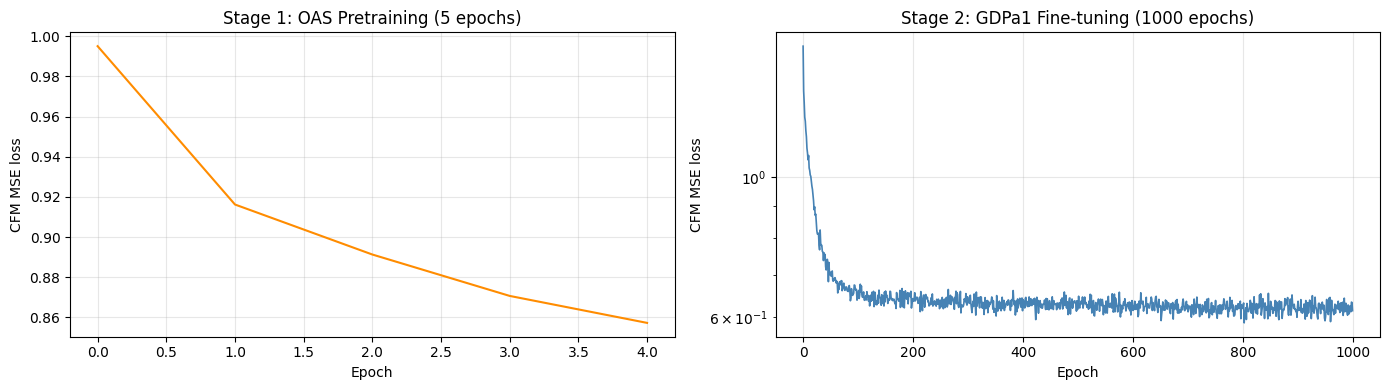

Flow model loaded from /content/drive/MyDrive/project/flow_model_pls_sigma0.5_finetuned.pt


In [24]:
# ── Load checkpoint ───────────────────────────────────────────────────────────
FLOW_CKPT = CACHE(f'flow_model_pls_sigma{CURRENT_SIGMA}_finetuned.pt')
flow_model = CDR3VelocityNetPLS(pls_dim=PLS_DIM, fw_dim=FW_DIM).to(DEVICE)
flow_model.load_state_dict(torch.load(FLOW_CKPT, map_location=DEVICE))
flow_model.eval()
losses = np.load(CACHE('flow_losses_finetuned.npy')).tolist()

# Plot both pretraining and fine-tuning losses
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pretrain_loss_path = CACHE('oas_pretrain_losses.npy')
if os.path.exists(pretrain_loss_path):
    pt_losses = np.load(pretrain_loss_path)
    axes[0].plot(pt_losses, lw=1.5, color='darkorange')
    axes[0].set(xlabel='Epoch', ylabel='CFM MSE loss',
                title=f'Stage 1: OAS Pretraining ({len(pt_losses)} epochs)')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No pretraining losses found',
                 ha='center', va='center', transform=axes[0].transAxes)

axes[1].plot(losses, lw=1.2, color='steelblue')
axes[1].set(xlabel='Epoch', ylabel='CFM MSE loss', yscale='log',
            title=f'Stage 2: GDPa1 Fine-tuning ({len(losses)} epochs)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Flow model loaded from {FLOW_CKPT}')

### 5b — OAS Pretraining Diagnostic: PLS Space Coverage

Visualize whether OAS pretraining has expanded the CDR3 manifold learned by the
flow model beyond the narrow GDPa1 cluster. We plot:
- GDPa1 training embeddings (grey)
- Random sample of 5,000 OAS embeddings projected to PLS space (blue)
- Flow targets for a representative test antibody (red stars)

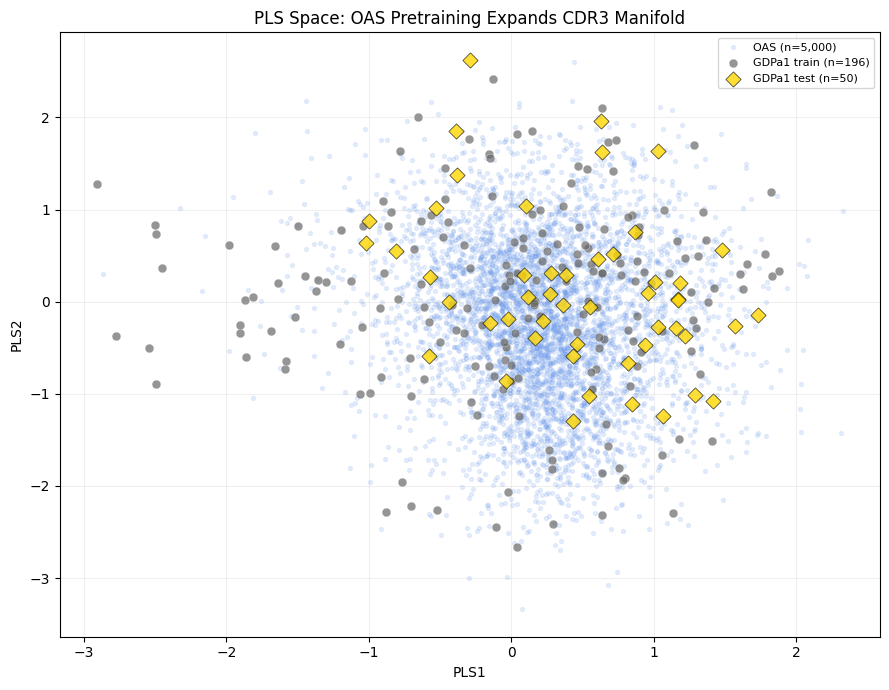

GDPa1 training points inside OAS 2D hull: 191/196 (97.4%)


In [25]:
# ── PLS space scatter: GDPa1 vs OAS vs flow targets ──────────────────────────
n_oas_plot = min(5000, len(oas_cdr3_pls_clean))
oas_plot_idx = np.random.choice(len(oas_cdr3_pls_clean), n_oas_plot, replace=False)
oas_plot = oas_cdr3_pls_clean[oas_plot_idx]

fig, ax = plt.subplots(figsize=(9, 7))

# OAS background
ax.scatter(oas_plot[:, 0], oas_plot[:, 1],
           c='cornflowerblue', s=8, alpha=0.15, label=f'OAS (n={n_oas_plot:,})')

# GDPa1 training
ax.scatter(X_pls_tr_sc[:, 0], X_pls_tr_sc[:, 1],
           c='dimgrey', s=40, alpha=0.7, edgecolors='white', linewidths=0.3,
           label=f'GDPa1 train (n={len(X_pls_tr_sc)})')

# GDPa1 test (parent positions)
ax.scatter(X_pls_te_sc[:, 0], X_pls_te_sc[:, 1],
           c='gold', s=60, marker='D', alpha=0.8, edgecolors='black', linewidths=0.5,
           label=f'GDPa1 test (n={len(X_pls_te_sc)})')

# Flow targets for first valid test antibody (if Phase 1 has run)
try:
    ex_local = valid_test_local[0]
    ex_global = test_idx[ex_local]
    ex_name  = df.iloc[ex_global].get(COL_NAME, f'Ab_{ex_global}')
    ex_tgts  = flow_targets[ex_name]  # (50, 10) PLS targets
    ax.scatter(ex_tgts[:, 0], ex_tgts[:, 1],
               c='red', s=50, marker='*', alpha=0.8,
               label=f'Flow targets ({ex_name}, n=50)')
except (NameError, KeyError):
    pass  # Phase 1 hasn't run yet

ax.set(xlabel='PLS1', ylabel='PLS2',
       title='PLS Space: OAS Pretraining Expands CDR3 Manifold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(CACHE('pls_oas_vs_gdpa1_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

# Quantitative: fraction of GDPa1 training points within OAS convex hull (approx)
from scipy.spatial import ConvexHull
try:
    hull_2d = ConvexHull(oas_plot[:, :2])
    from matplotlib.path import Path
    hull_path = Path(oas_plot[hull_2d.vertices, :2])
    inside = hull_path.contains_points(X_pls_tr_sc[:, :2])
    print(f'GDPa1 training points inside OAS 2D hull: '
          f'{inside.sum()}/{len(X_pls_tr_sc)} ({100*inside.mean():.1f}%)')
except Exception:
    print('(ConvexHull diagnostic skipped)')

### 5c — Ablation: GDPa1 Training Without OAS Pretraining
Train a fresh flow model from scratch on only the GDPa1 data to see if the OAS pretraining actually helps.

Loaded non-pretrained model from /content/drive/MyDrive/project/flow_model_pls_sigma0.5_no_pretrain.pt


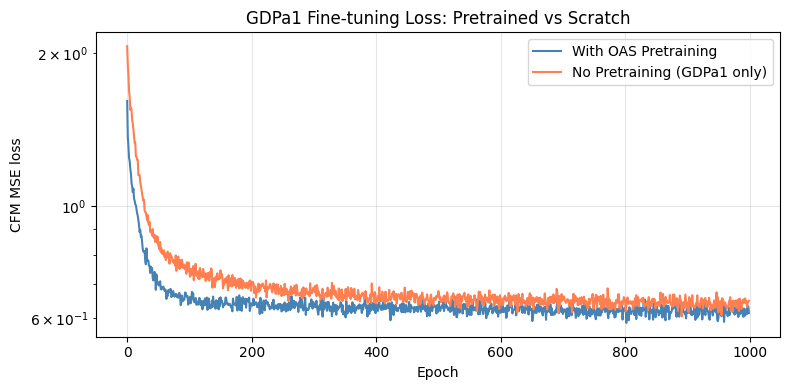

In [26]:
FLOW_CKPT_NO_PT = CACHE(f'flow_model_pls_sigma{CURRENT_SIGMA}_no_pretrain.pt')

if os.path.exists(FLOW_CKPT_NO_PT):
    flow_model_no_pt = CDR3VelocityNetPLS(pls_dim=PLS_DIM, fw_dim=FW_DIM).to(DEVICE)
    flow_model_no_pt.load_state_dict(torch.load(FLOW_CKPT_NO_PT, map_location=DEVICE))
    flow_model_no_pt.eval()
    losses_no_pt = np.load(CACHE('flow_losses_no_pretrain.npy')).tolist()
    print(f'Loaded non-pretrained model from {FLOW_CKPT_NO_PT}')
else:
    print('Training fresh flow model ON GDPa1 ONLY (no OAS pretraining)...')
    flow_model_no_pt = CDR3VelocityNetPLS(pls_dim=PLS_DIM, fw_dim=FW_DIM).to(DEVICE)
    opt_no_pt = AdamW(flow_model_no_pt.parameters(), lr=OAS_FINETUNE_LR, weight_decay=1e-4)
    sch_no_pt = CosineAnnealingLR(opt_no_pt, T_max=FLOW_EPOCHS, eta_min=1e-6)
    losses_no_pt = []

    for epoch in range(FLOW_EPOCHS):
        flow_model_no_pt.train()
        ep = 0.0
        for x1, fw, dev in loader:  # Reusing the augmented GDPa1 loader from Stage 2
            x1, fw, dev = x1.to(DEVICE), fw.to(DEVICE), dev.to(DEVICE)
            x0           = torch.randn_like(x1)
            t, xt, ut    = FM.sample_location_and_conditional_flow(x0, x1)
            vt           = flow_model_no_pt(t, xt, fw, dev)
            loss         = F.mse_loss(vt, ut)
            opt_no_pt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(flow_model_no_pt.parameters(), 1.0)
            opt_no_pt.step(); ep += loss.item()
        sch_no_pt.step()
        losses_no_pt.append(ep / len(loader))
        if (epoch + 1) % 200 == 0:
            print(f'  No-PT Epoch {epoch+1:4d} | CFM loss: {losses_no_pt[-1]:.5f}')

    torch.save(flow_model_no_pt.state_dict(), FLOW_CKPT_NO_PT)
    np.save(CACHE('flow_losses_no_pretrain.npy'), np.array(losses_no_pt))
    print(f'Saved non-pretrained model to {FLOW_CKPT_NO_PT}')

flow_model_no_pt.eval()

# Compare losses
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(losses, lw=1.5, color='steelblue', label='With OAS Pretraining')
ax.plot(losses_no_pt, lw=1.5, color='coral', label='No Pretraining (GDPa1 only)')
ax.set(xlabel='Epoch', ylabel='CFM MSE loss', yscale='log',
       title='GDPa1 Fine-tuning Loss: Pretrained vs Scratch')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

---
## Section 6 — Phase 1: Free ODE Sampling

For each test antibody, draw N=50 independent noise vectors from N(0,I) in PLS
space and integrate the flow model ODE to completion (t=0→1).

**Key design decisions:**
- The framework embedding is fixed for all 50 trajectories — diversity comes
  from the noise seeds, not from varying the framework
- The developability target is set to the 20th percentile of training scores —
  ambitious but realistic given the training distribution
- The oracle is NOT called here — intermediate ODE states are not on the
  manifold of valid protein embeddings and oracle scores there are meaningless

In [27]:
def sample_flow_targets(flow_model, fw_cond_sc, dev_target_sc,
                         n_samples=50, n_steps=100, device=DEVICE):
    """
    Draw n_samples ODE trajectories from the flow model.

    fw_cond_sc  : (1, fw_dim)  scaled masked-framework embedding — fixed per parent
    dev_target_sc: (1, 2)      target (HIC, AC-SINS) in scaled space — set to
                               values better than the parent
    Returns    : (n_samples, pls_dim) CDR3 PLS-space targets at t=1
    """
    flow_model.eval()
    fw  = torch.tensor(fw_cond_sc,  dtype=torch.float32).to(device)
    dev = torch.tensor(dev_target_sc, dtype=torch.float32).to(device)
    fw  = fw.expand(n_samples, -1)
    dev = dev.expand(n_samples, -1)
    x   = torch.randn(n_samples, PLS_DIM, device=device)

    def ode_fn(t, y):
        t_batch = t.expand(y.shape[0])
        return flow_model(t_batch, y, fw, dev)

    t_span = torch.linspace(0, 1, n_steps + 1, device=device)
    with torch.no_grad():
        traj = odeint(ode_fn, x, t_span, method='euler')
    return traj[-1].cpu().numpy()  # (n_samples, pls_dim)


# Identify test antibodies with valid CDR3 sequences
valid_test_local = [
    i for i in range(len(test_idx))
    if isinstance(df['hcdr3_sequence'].values[test_idx[i]], str)
    and len(df['hcdr3_sequence'].values[test_idx[i]]) > 0]
print(f'Valid test antibodies: {len(valid_test_local)}')

# Set developability target = 20th percentile of training scores
# (ambitious improvement but within the observed training distribution)
target_hic  = np.percentile(y_hic_train,  20)
target_sins = np.percentile(y_sins_train, 20)
dev_target_raw = np.array([[target_hic, target_sins]])
dev_target_sc  = dev_scaler.transform(dev_target_raw)
print(f'Dev target: HIC={target_hic:.3f}  SINS={target_sins:.3f}')
print(f'  (20th pctile of training — more developable than most parents)')

# Run Phase 1 for all test antibodies
flow_targets = {}  # ab_name -> (N, pls_dim)

print(f'\nRunning Phase 1 for {len(valid_test_local)} test antibodies...')
for local_i in valid_test_local:
    global_i = test_idx[local_i]
    ab_name  = df.iloc[global_i].get(COL_NAME, f'Ab_{global_i}')
    fw_cond  = X_fw_te[[local_i]]  # (1, fw_dim)
    targets  = sample_flow_targets(
        flow_model, fw_cond, dev_target_sc,
        n_samples=N_FLOW_SAMPLES, n_steps=N_ODE_STEPS)
    flow_targets[ab_name] = targets  # (50, 10)

print(f'Phase 1 complete: {len(flow_targets)} × {N_FLOW_SAMPLES} targets')

Valid test antibodies: 50
Dev target: HIC=2.560  SINS=-0.375
  (20th pctile of training — more developable than most parents)

Running Phase 1 for 50 test antibodies...
Phase 1 complete: 50 × 50 targets


### 6a — Flow target analysis

Flow target diagnostics for abagovomab:
  NN dist to train manifold: 1.712  (lower = more on-manifold)
  Target diversity:          2.120  (higher = more spread)
  Parent→centroid distance:  1.254  (0 = no shift from parent)


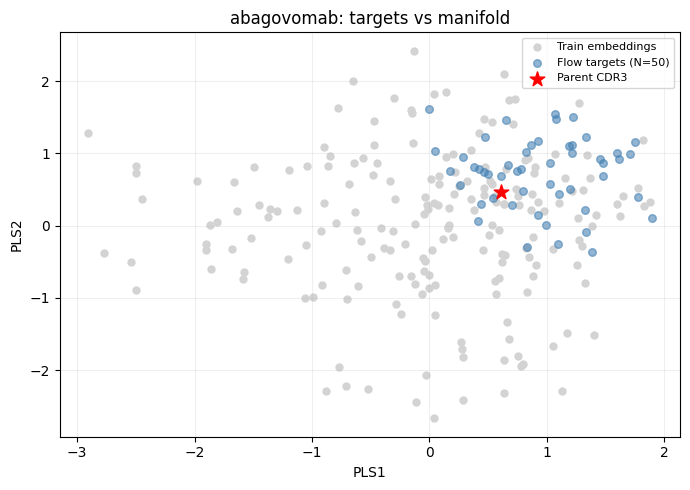

In [28]:
# Diagnose the quality of Phase  1 outputs before proceeding to Phase 2.
# Key questions:
# (1) Are targets on the training manifold? (low NN dist = good)
# (2) Are they diverse? (high pairwise dist = good)
# (3) Do they shift toward better developability?

example_local_i = valid_test_local[0]
example_global  = test_idx[example_local_i]
example_name    = df.iloc[example_global].get(COL_NAME, f'Ab_{example_global}')
example_targets = flow_targets[example_name]  # (50, 10) PLS targets

# Training PLS embeddings in same space
train_pls = X_pls_tr_sc

nn_dist   = scipy_cdist(example_targets, train_pls).min(axis=1).mean()
pw        = scipy_cdist(example_targets, example_targets)
diversity = pw[np.triu_indices(len(example_targets), k=1)].mean()
parent_pt = X_pls_te_sc[[example_local_i]]
centroid  = example_targets.mean(0, keepdims=True)
shift     = scipy_cdist(parent_pt, centroid)[0, 0]

print(f'Flow target diagnostics for {example_name}:')
print(f'  NN dist to train manifold: {nn_dist:.3f}  (lower = more on-manifold)')
print(f'  Target diversity:          {diversity:.3f}  (higher = more spread)')
print(f'  Parent→centroid distance:  {shift:.3f}  (0 = no shift from parent)')

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_pls[:,0], train_pls[:,1],
           c='lightgrey', s=25, label='Train embeddings')
ax.scatter(example_targets[:,0], example_targets[:,1],
           c='steelblue', s=30, alpha=0.6, label='Flow targets (N=50)')
ax.scatter(parent_pt[0,0], parent_pt[0,1],
           c='red', s=120, marker='*', label='Parent CDR3')
ax.set(xlabel='PLS1', ylabel='PLS2', title=f'{example_name}: targets vs manifold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

In [29]:
from scipy.stats import spearmanr
for k in range(3):
    rho_h, _ = spearmanr(X_pls_tr_sc[:, k], y_hic_train)
    rho_s, _ = spearmanr(X_pls_tr_sc[:, k], y_sins_train)
    print(f'PLS{k+1}: HIC ρ={rho_h:+.3f}  SINS ρ={rho_s:+.3f}')

PLS1: HIC ρ=+0.291  SINS ρ=-0.570
PLS2: HIC ρ=-0.374  SINS ρ=-0.326
PLS3: HIC ρ=-0.388  SINS ρ=-0.100


### 6d — Ablation: Target Quality (Pretrained vs Scratch)

Evaluate the targets generated by the non-pretrained model and compare them to the pretrained model's targets for the same antibody.

Evaluating targets for abagovomab...

Metrics for abagovomab (N=50 targets):
Metric                    | Pretrained   | Scratch     
-------------------------------------------------------
NN dist to train (lower=better) | 1.712        | 1.559       
Diversity (higher=better) | 2.120        | 2.080       
Shift from parent         | 1.254        | 1.247       


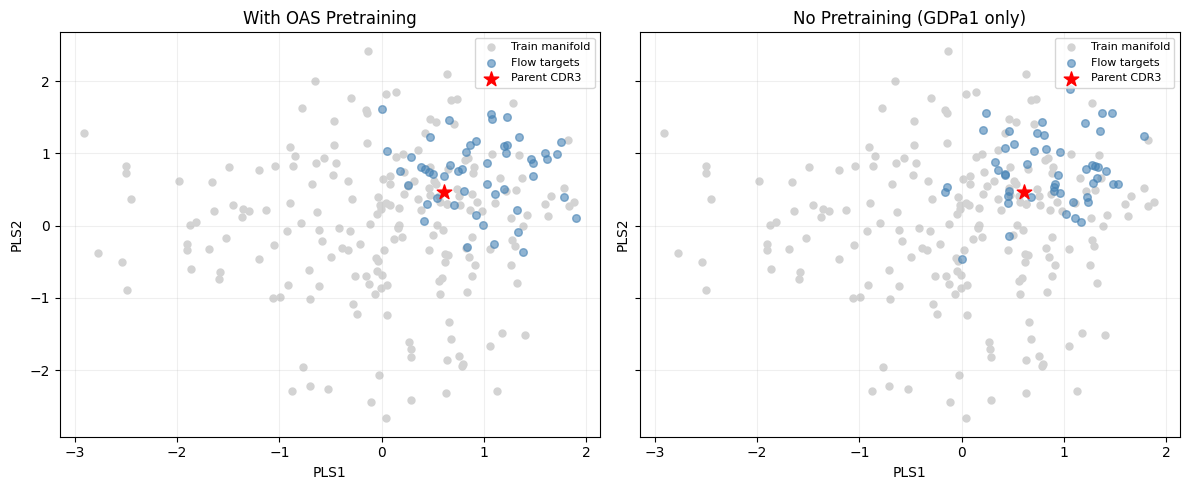

In [30]:
example_local_i = valid_test_local[0]
example_global  = test_idx[example_local_i]
example_name    = df.iloc[example_global].get(COL_NAME, f'Ab_{example_global}')

print(f'Evaluating targets for {example_name}...')

# 1. Get targets from the PRETRAINED model (already computed in Section 6, but we need it here if run out of order)
# If Section 6 hasn't run, we compute it on the fly.
fw_cond = X_fw_te[[example_local_i]]
if 'flow_targets' in locals() and example_name in flow_targets:
    targets_pt = flow_targets[example_name]
else:
    target_hic  = np.percentile(y_hic_train,  20)
    target_sins = np.percentile(y_sins_train, 20)
    dev_target_raw = np.array([[target_hic, target_sins]])
    dev_target_sc  = dev_scaler.transform(dev_target_raw)
    targets_pt = sample_flow_targets(flow_model, fw_cond, dev_target_sc, n_samples=N_FLOW_SAMPLES, n_steps=N_ODE_STEPS)

# 2. Get targets from the NON-PRETRAINED model
targets_no_pt = sample_flow_targets(flow_model_no_pt, fw_cond, dev_target_sc, n_samples=N_FLOW_SAMPLES, n_steps=N_ODE_STEPS)

# Metrics
train_pls = X_pls_tr_sc
parent_pt = X_pls_te_sc[[example_local_i]]

def calc_metrics(targets):
    nn_dist   = scipy_cdist(targets, train_pls).min(axis=1).mean()
    pw        = scipy_cdist(targets, targets)
    diversity = pw[np.triu_indices(len(targets), k=1)].mean()
    shift     = scipy_cdist(parent_pt, targets.mean(0, keepdims=True))[0, 0]
    return nn_dist, diversity, shift

pt_nn, pt_div, pt_shift = calc_metrics(targets_pt)
nopt_nn, nopt_div, nopt_shift = calc_metrics(targets_no_pt)

print(f'\nMetrics for {example_name} (N=50 targets):')
print(f'{"Metric":<25} | {"Pretrained":<12} | {"Scratch":<12}')
print('-' * 55)
print(f'{"NN dist to train (lower=better)":<25} | {pt_nn:<12.3f} | {nopt_nn:<12.3f}')
print(f'{"Diversity (higher=better)":<25} | {pt_div:<12.3f} | {nopt_div:<12.3f}')
print(f'{"Shift from parent":<25} | {pt_shift:<12.3f} | {nopt_shift:<12.3f}')

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, targets, title in zip(axes, [targets_pt, targets_no_pt], ['With OAS Pretraining', 'No Pretraining (GDPa1 only)']):
    ax.scatter(train_pls[:,0], train_pls[:,1], c='lightgrey', s=25, label='Train manifold')
    ax.scatter(targets[:,0], targets[:,1], c='steelblue', s=30, alpha=0.6, label='Flow targets')
    ax.scatter(parent_pt[0,0], parent_pt[0,1], c='red', s=120, marker='*', label='Parent CDR3')
    ax.set(xlabel='PLS1', ylabel='PLS2', title=title)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Section 7 — Phase 2: AbLang2 Masked Pass + Distance Matrix

For each parent antibody:
1. **One masked forward pass** — replace CDR3 positions with `*`, run AbLang2
   to get `(L, 20)` joint token probabilities for all CDR3 positions at once
2. **Temperature sampling** — sample M=20 complete CDR3 sequences from those
   logits (pure tensor ops, no extra forward pass)
3. **One batched rescoring call** — graft each candidate CDR3 into the parent VH,
   run AbLang2 rescoding on all M sequences in one batch
4. **Map to PLS space** — project the M sequence CDR3 embeddings to PLS space
5. **Distance matrix `(N=50, M=20)`** — for each flow target, find the closest
   sequence in PLS space. Select top-k unique pairs for Phase 3.

In [31]:
def get_cdr3_mlm_logits(ablang, masked_vh, vl_seq, cdr3_positions):
    """
    Single AbLang2 masked forward pass.
    Returns (L, 20) log-softmax probabilities over standard AAs
    at the CDR3 (masked) positions.

    Why one pass instead of L passes:
    AbLang2 attends to all positions simultaneously — the joint (L, 20)
    output captures inter-position dependencies that L independent
    single-position predictions would miss.
    """
    with torch.no_grad():
        reps = ablang([(masked_vh, vl_seq)], mode='rescoding')
    hidden_np = np.array(reps[0])
    vh_len    = len(masked_vh)
    vl_len    = len(vl_seq)
    n_ex      = hidden_np.shape[0] - vh_len - vl_len
    vh_hid    = hidden_np[:vh_len]
    cdr3_hid  = vh_hid[cdr3_positions]  # (L, 480)
    cdr3_t    = torch.tensor(cdr3_hid, dtype=torch.float32).to(DEVICE)
    try:
        with torch.no_grad():
            logits = ablang.AbLang.AbHead(cdr3_t)
    except AttributeError:
        for attr in ['AbHead', 'lm_head', 'predictions', 'cls']:
            head = getattr(ablang.AbLang, attr, None)
            if head is not None:
                with torch.no_grad(): logits = head(cdr3_t)
                break
        else:
            raise RuntimeError('Cannot find AbLang2 MLM head.')
    try:
        vocab      = ablang.tokenizer.vocab
        aa_indices = torch.tensor(
            [vocab[aa] for aa in AA_VOCAB if aa in vocab], dtype=torch.long)
        aa_logits  = logits[:, aa_indices] if len(aa_indices) == 20 else logits[:, :20]
    except (AttributeError, KeyError):
        aa_logits = logits[:, :20]
    return F.log_softmax(aa_logits, dim=-1).cpu().numpy()  # (L, 20)


def temperature_sample_sequences(log_probs, M=20, temperature=1.0, seed=None):
    """
    Sample M CDR3 sequences from (L, 20) log-probabilities.
    Higher temperature = more diversity from AbLang2's distribution.
    Returns list of M strings, each length L = len(parent_CDR3).
    Length is guaranteed because we placed exactly L mask tokens.
    """
    if seed is not None: np.random.seed(seed)
    probs = np.exp(log_probs / temperature)
    probs = probs / probs.sum(axis=1, keepdims=True)
    L = log_probs.shape[0]
    return [''.join(AA_VOCAB[np.random.choice(20, p=probs[pos])]
                   for pos in range(L))
            for _ in range(M)]


def splice_cdr3(parent_vh, cdr3_positions, new_cdr3):
    """Graft new_cdr3 residues into parent_vh at cdr3_positions."""
    chars = list(parent_vh)
    for j, pos in enumerate(cdr3_positions):
        if pos < len(chars) and j < len(new_cdr3):
            chars[pos] = new_cdr3[j]
    return ''.join(chars)


def rescore_sequences(ablang, spliced_vhs, parent_vl, cdr3_positions):
    """
    Batched AbLang2 rescoding for M sequences.
    Returns (M, 480) CDR3 sub-embeddings, unscaled.
    One batched call is much cheaper than M individual calls.
    """
    seqs = [(vh, parent_vl) for vh in spliced_vhs]
    with torch.no_grad():
        reps = ablang(seqs, mode='rescoding')
    embs = []
    for j, vh in enumerate(spliced_vhs):
        hidden = np.array(reps[j])
        h_hid  = hidden[:len(vh)]
        valid  = [k for k in cdr3_positions if k < len(h_hid)]
        embs.append(h_hid[valid].mean(0) if valid else np.zeros(480))
    return np.vstack(embs)  # (M, 480)

In [32]:
def guided_sample_sequences(log_probs, flow_target_pls,
                             parent_vh, parent_vl, cdr3_idx,
                             ablang, pls_model, pls_scaler,
                             M=20, temperature=1.0,
                             guidance_strength=2.0, top_k_tokens=5):
    """
    Sample M CDR3 sequences from AbLang2 logits steered toward
    the flow model's PLS target.

    For each position, evaluate the top_k_tokens most likely amino acids.
    Re-weight their probabilities based on how much placing each token
    moves the sequence embedding toward the flow target in PLS space.
    Then sample from the re-weighted distribution.

    guidance_strength: how hard to push toward the flow target
                       0 = pure AbLang2 (identical to baseline)
                       higher = stronger steering
    """
    L      = log_probs.shape[0]
    # Start with a greedy sequence to fill in non-evaluated positions
    greedy = [AA_VOCAB[log_probs[pos].argmax()] for pos in range(L)]

    # Build steered probability distribution for each position
    steered_log_probs = log_probs.copy()   # (L, 20)

    for pos in range(L):
        base_probs = np.exp(log_probs[pos] / temperature)
        base_probs /= base_probs.sum()

        # Only evaluate the top_k most likely tokens per position
        # (evaluating all 20 would require 20 AbLang2 forward passes per position)
        top_k_idx = np.argsort(base_probs)[-top_k_tokens:]

        steering_bonus = np.zeros(20)

        for aa_idx in top_k_idx:
            # Build a trial sequence: this token at pos, greedy elsewhere
            trial = greedy.copy()
            trial[pos] = AA_VOCAB[aa_idx]
            trial_cdr3 = ''.join(trial)
            trial_vh   = splice_cdr3(parent_vh, cdr3_idx, trial_cdr3)

            # Re-embed and project to PLS space — one AbLang2 forward pass
            with torch.no_grad():
                reps = ablang([(trial_vh, parent_vl)], mode='rescoding')
            hidden   = np.array(reps[0])[:len(trial_vh)]
            valid    = [i for i in cdr3_idx if i < len(hidden)]
            cdr3_emb = hidden[valid].mean(0, keepdims=True)   # (1, 480)
            cdr3_pls = pls_scaler.transform(
                pls_model.transform(cdr3_emb))                # (1, 10)

            # Reward tokens that move the embedding toward the flow target
            dist = np.linalg.norm(cdr3_pls - flow_target_pls)
            steering_bonus[aa_idx] = -dist   # higher = closer to target

        # Re-weight: combine AbLang2 prior with steering signal
        steering_bonus -= steering_bonus[top_k_idx].max()   # numerical stability
        steering_weight = np.exp(guidance_strength * steering_bonus)
        steering_weight[steering_bonus == 0] = 0            # zero unevaluated tokens

        combined  = base_probs * (1 + steering_weight)
        combined /= combined.sum()

        steered_log_probs[pos] = np.log(combined + 1e-12)

    # Now sample M sequences from the steered distribution
    return temperature_sample_sequences(
        steered_log_probs, M=M, temperature=temperature)


```

With this change the pipeline becomes:
```
Phase 2 (new):
  Flow target (10d PLS) → modify AbLang2 logits at each position
  Sample M=20 sequences from steered distribution
  → All 20 candidates already biased toward flow target
  Oracle picks best from all 20 (no distance matrix needed)

In [33]:
GUIDANCE_STRENGTH = 2.0   # how hard to push toward flow target
                           # 0 = pure AbLang2 (identical to baseline)
                           # higher = stronger steering
top_k_tokens      = 5     # AbLang2 tokens evaluated per position
                           # cost = TOP_K_TOKENS × CDR3_length forward passes
                           # per sequence — reduce to 3 if too slow
generation_records = []

print(f'Running Phase 2 (steered) for {len(valid_test_local)} test antibodies...')
print(f'  Steering: {top_k_tokens} tokens evaluated per CDR3 position')
print(f'  Oracle scores all {M_SEQUENCES} candidates per antibody\n')

for local_i in valid_test_local:
    global_i    = test_idx[local_i]
    row         = df.iloc[global_i]
    ab_name     = row.get(COL_NAME, f'Ab_{global_i}')
    parent_vh   = row[COL_VH]
    parent_vl   = row[COL_VL]
    cdr3_idx    = row['h_cdr3_idx']
    parent_cdr3 = row['hcdr3_sequence']

    # Step 1: one masked forward pass — get AbLang2 base logits
    masked_vh = mask_cdr3(parent_vh, cdr3_idx)
    log_probs = get_cdr3_mlm_logits(
        ablang, masked_vh, parent_vl, cdr3_idx)   # (L, 20)

    # Step 2: steered sampling
    # Flow target = centroid of the 50 Phase 1 targets (one steering direction
    # per parent antibody, derived from the flow model's learned distribution)
    flow_centroid = flow_targets[ab_name].mean(0, keepdims=True)   # (1, 10)

    cdr3_candidates = guided_sample_sequences(
        log_probs         = log_probs,
        flow_target_pls   = flow_centroid,
        parent_vh         = parent_vh,
        parent_vl         = parent_vl,
        cdr3_idx          = cdr3_idx,
        ablang            = ablang,
        pls_model         = pls,
        pls_scaler        = pls_scaler,
        M                 = M_SEQUENCES,
        temperature       = TEMPERATURE,
        guidance_strength = 2.0,
        top_k_tokens      = 5)

    # Step 3: reconstruct full VH for each candidate
    spliced_vhs = [splice_cdr3(parent_vh, cdr3_idx, c)
                   for c in cdr3_candidates]

    generation_records.append({
        'ab_name':         ab_name,
        'global_idx':      global_i,
        'local_idx':       local_i,
        'parent_vh':       parent_vh,
        'parent_vl':       parent_vl,
        'parent_cdr3':     parent_cdr3,
        'cdr3_idx':        cdr3_idx,
        'cdr3_candidates': cdr3_candidates,   # M steered sequences
        'spliced_vhs':     spliced_vhs,
    })
    print(f'  ✓ {ab_name}  len={len(parent_cdr3)}')

print(f'\nPhase 2 complete: {len(generation_records)} antibodies processed.')

Running Phase 2 (steered) for 50 test antibodies...
  Steering: 5 tokens evaluated per CDR3 position
  Oracle scores all 20 candidates per antibody

  ✓ abagovomab  len=12
  ✓ abituzumab  len=11
  ✓ abrilumab  len=11
  ✓ amatuximab  len=12
  ✓ basiliximab  len=10
  ✓ bavituximab  len=13
  ✓ belantamab  len=14
  ✓ bemarituzumab  len=7
  ✓ benralizumab  len=14
  ✓ blosozumab  len=11
  ✓ bococizumab  len=11
  ✓ brontictuzumab  len=14
  ✓ burosumab  len=10
  ✓ coltuximab  len=13
  ✓ crizanlizumab  len=15
  ✓ daclizumab  len=9
  ✓ eculizumab  len=15
  ✓ emactuzumab  len=10
  ✓ emibetuzumab  len=8
  ✓ enokizumab  len=15
  ✓ epratuzumab  len=9
  ✓ fasinumab  len=12
  ✓ fletikumab  len=20
  ✓ galcanezumab  len=12
  ✓ gemtuzumab  len=9
  ✓ imgatuzumab  len=13
  ✓ inotuzumab  len=14
  ✓ lampalizumab  len=8
  ✓ lintuzumab  len=9
  ✓ loncastuximab  len=13
  ✓ matuzumab  len=14
  ✓ mirikizumab  len=8
  ✓ monalizumab  len=18
  ✓ muromonab  len=12
  ✓ natalizumab  len=16
  ✓ nimotuzumab  len=16
  ✓ o

---
## Section 8 — Phase 3: Oracle Scoring

The oracle only scores **fully assembled, valid sequences**.
Input: `ablang.seqcoding(VH, VL)` → 480d → scaled → Ridge prediction.
This is the same input format the oracle was trained on.

The oracle acts as a final selector among the top-k Phase 2 candidates.
It never influences what gets generated — only which candidate is returned.

In [34]:
def oracle_score(vh_seq, vl_seq, use_lora = USE_LORA_ORACLE):
    """
    Score a fully assembled (VH, VL) pair with both oracle heads.
    Uses seqcoding (mean-pooled full sequence) — same as oracle training input.
    Returns dict with 'hic', 'sins', 'full_emb_sc'.

    If USE_LORA_ORACLE=True:
        Uses fine-tuned LoRA encoder + regression heads
    Else:
        Uses frozen AbLang2 + Ridge regression (baseline)

    Returns dict with 'hic', 'sins', and optionally 'full_emb_sc'.
    """
    if use_lora and lora_encoder is not None:
        # LoRA oracle path
        with torch.no_grad():
            tokens = lora_encoder.tokenize([vh_seq], [vl_seq], DEVICE)
            emb = lora_encoder(tokens)
            hic_pred = float(lora_head_hic(emb).cpu().numpy()[0])
            sins_pred = float(lora_head_sins(emb).cpu().numpy()[0])
        return {
            'hic':  hic_pred,
            'sins': sins_pred,
        }
    else:
        # Ridge oracle path (original baseline)
        with torch.no_grad():
            emb = ablang([(vh_seq, vl_seq)], mode='seqcoding')
        emb_sc = full_scaler.transform(np.array(emb).reshape(1, -1))
        return {
            'hic':         float(oracle_hic.predict(emb_sc)[0]),
            'sins':        float(oracle_sins.predict(emb_sc)[0]),
            'full_emb_sc': emb_sc[0],
        }

results = []

for rec in generation_records:
    ab_name  = rec['ab_name']

    # Score parent
    par = oracle_score(rec['parent_vh'], rec['parent_vl'])

    # Unguided: first candidate in the list
    # (all candidates are steered, so index 0 is just one steered sample —
    # use the baseline_df from Section 9 for a true unguided comparison)
    ung = oracle_score(rec['spliced_vhs'][0], rec['parent_vl'])

    # Oracle scores ALL M steered candidates and picks the global best
    best_score, best = None, None
    for sj, (cdr3, vh) in enumerate(
            zip(rec['cdr3_candidates'], rec['spliced_vhs'])):
        sc = oracle_score(vh, rec['parent_vl'])
        zh = (sc['hic']  - y_hic_train.mean()) / (y_hic_train.std()  + 1e-8)
        zs = (sc['sins'] - y_sins_train.mean()) / (y_sins_train.std() + 1e-8)
        if best_score is None or (zh + zs) < best_score:
            best_score = zh + zs
            best       = (sj, sc)

    results.append({
        'ab_name':              ab_name,
        'parent_vh':            rec['parent_vh'],
        'parent_vl':            rec['parent_vl'],
        'parent_cdr3':          rec['parent_cdr3'],
        'guided_cdr3':          rec['cdr3_candidates'][best[0]],
        'guided_vh':            rec['spliced_vhs'][best[0]],
        'unguided_cdr3':        rec['cdr3_candidates'][0],
        'unguided_vh':          rec['spliced_vhs'][0],
        'oracle_hic_parent':    par['hic'],
        'oracle_sins_parent':   par['sins'],
        'oracle_hic_guided':    best[1]['hic'],
        'oracle_sins_guided':   best[1]['sins'],
        'oracle_hic_unguided':  ung['hic'],
        'oracle_sins_unguided': ung['sins'],
        'h_cdr3_idx':           rec['cdr3_idx'],
    })
    print(f'  ✓ {ab_name}  '
          f'HIC: {par["hic"]:+.3f}→{best[1]["hic"]:+.3f}  '
          f'SINS: {par["sins"]:+.3f}→{best[1]["sins"]:+.3f}')

seq_df = pd.DataFrame(results)
seq_df.to_csv(CACHE('seq_df.csv'), index=False)
print(f'\nSaved {len(seq_df)} results.')

  ✓ abagovomab  HIC: +3.083→+3.024  SINS: +19.075→+13.230
  ✓ abituzumab  HIC: +2.705→+2.725  SINS: +8.425→+4.615
  ✓ abrilumab  HIC: +2.745→+1.765  SINS: -10.797→-13.229
  ✓ amatuximab  HIC: +2.639→+2.523  SINS: +4.656→+0.443
  ✓ basiliximab  HIC: +2.934→+2.562  SINS: +20.353→+13.833
  ✓ bavituximab  HIC: +2.309→+1.916  SINS: +2.422→-3.805
  ✓ belantamab  HIC: +2.960→+2.716  SINS: +11.020→+6.610
  ✓ bemarituzumab  HIC: +2.438→+2.161  SINS: -1.524→-9.308
  ✓ benralizumab  HIC: +2.551→+2.513  SINS: -3.640→-6.765
  ✓ blosozumab  HIC: +2.798→+2.602  SINS: -4.587→-9.887
  ✓ bococizumab  HIC: +2.125→+2.184  SINS: +15.609→+12.562
  ✓ brontictuzumab  HIC: +3.286→+3.034  SINS: +5.335→-3.806
  ✓ burosumab  HIC: +3.017→+2.821  SINS: +0.960→-6.793
  ✓ coltuximab  HIC: +2.723→+2.332  SINS: -0.126→-6.196
  ✓ crizanlizumab  HIC: +2.490→+2.379  SINS: -8.579→-6.943
  ✓ daclizumab  HIC: +3.244→+2.650  SINS: +1.372→-1.735
  ✓ eculizumab  HIC: +2.808→+2.706  SINS: +4.313→-3.181
  ✓ emactuzumab  HIC: +2.6

---
## Section 9 — AbLang2-Only Baseline

The baseline skips Phase 1 (flow model) entirely. AbLang2's masked pass generates
M=20 candidates and the oracle selects the best — no distance matrix filtering.

This isolates the flow model's contribution. If baseline outperforms guided,
it means the flow model's distance matrix filter is removing good candidates
(i.e. off-manifold targets are corrupting the selection).

In [35]:
baseline_records = []

print('Running AbLang2-only baseline (no flow model)...')
for local_i in valid_test_local:
    global_i    = test_idx[local_i]
    row         = df.iloc[global_i]
    ab_name     = row.get(COL_NAME, f'Ab_{global_i}')
    parent_vh   = row[COL_VH]
    parent_vl   = row[COL_VL]
    cdr3_idx    = row['h_cdr3_idx']

    # Same masked pass as Phase 2 — one forward call
    log_probs   = get_cdr3_mlm_logits(
        ablang, mask_cdr3(parent_vh, cdr3_idx),
        parent_vl, cdr3_idx)
    candidates  = temperature_sample_sequences(
        log_probs, M=M_SEQUENCES, temperature=TEMPERATURE,
        seed=int(global_i))
    spliced     = [splice_cdr3(parent_vh, cdr3_idx, c) for c in candidates]

    # Oracle sees ALL M candidates — no distance matrix pre-filter
    best_score, best_hic, best_sins, best_cdr3 = None, None, None, None
    for cdr3, vh in zip(candidates, spliced):
        sc = oracle_score(vh, parent_vl)
        zh = (sc['hic']  - y_hic_train.mean()) / (y_hic_train.std()  + 1e-8)
        zs = (sc['sins'] - y_sins_train.mean()) / (y_sins_train.std() + 1e-8)
        if best_score is None or (zh + zs) < best_score:
            best_score = zh + zs
            best_hic, best_sins, best_cdr3 = sc['hic'], sc['sins'], cdr3

    baseline_records.append({
        'ab_name':              ab_name,
        'baseline_cdr3':        best_cdr3,
        'oracle_hic_baseline':  best_hic,
        'oracle_sins_baseline': best_sins,
    })
    print(f'  ✓ {ab_name}  HIC={best_hic:.3f}  SINS={best_sins:.3f}')

baseline_df = pd.DataFrame(baseline_records)

compare_df = seq_df.merge(
    baseline_df[['ab_name','oracle_hic_baseline',
                 'oracle_sins_baseline','baseline_cdr3']],
    on='ab_name', how='inner')
print(f'\nComparison dataframe: {len(compare_df)} antibodies')

# Summary
print(f'\n{"Condition":<28} {"HIC":>14} {"SINS":>14}')
print('─' * 58)
for label, hc, sc_ in [
        ('Parent',             'oracle_hic_parent',   'oracle_sins_parent'),
        ('Baseline (AbLang2)', 'oracle_hic_baseline', 'oracle_sins_baseline'),
        ('Guided (flow)',      'oracle_hic_guided',   'oracle_sins_guided')]:
    h = compare_df[hc]
    s = compare_df[sc_]
    print(f'{label:<28} {h.mean():>+6.3f}±{h.sem():.3f}  '
          f'{s.mean():>+6.3f}±{s.sem():.3f}')

Running AbLang2-only baseline (no flow model)...
  ✓ abagovomab  HIC=3.076  SINS=17.270
  ✓ abituzumab  HIC=2.774  SINS=7.136
  ✓ abrilumab  HIC=1.971  SINS=-18.502
  ✓ amatuximab  HIC=2.645  SINS=2.205
  ✓ basiliximab  HIC=2.513  SINS=15.151
  ✓ bavituximab  HIC=2.029  SINS=-1.737
  ✓ belantamab  HIC=2.740  SINS=0.605
  ✓ bemarituzumab  HIC=2.447  SINS=-13.138
  ✓ benralizumab  HIC=2.241  SINS=-7.952
  ✓ blosozumab  HIC=2.650  SINS=-7.158
  ✓ bococizumab  HIC=1.869  SINS=13.294
  ✓ brontictuzumab  HIC=3.102  SINS=4.063
  ✓ burosumab  HIC=2.471  SINS=-4.640
  ✓ coltuximab  HIC=2.486  SINS=-0.306
  ✓ crizanlizumab  HIC=2.120  SINS=-5.320
  ✓ daclizumab  HIC=2.720  SINS=-5.301
  ✓ eculizumab  HIC=2.154  SINS=5.572
  ✓ emactuzumab  HIC=2.466  SINS=-0.673
  ✓ emibetuzumab  HIC=2.173  SINS=3.922
  ✓ enokizumab  HIC=2.573  SINS=3.318
  ✓ epratuzumab  HIC=2.370  SINS=2.181
  ✓ fasinumab  HIC=2.512  SINS=-12.654
  ✓ fletikumab  HIC=2.614  SINS=-2.996
  ✓ galcanezumab  HIC=2.775  SINS=5.826
  ✓

## Section 9b — LoRA Oracle Test Set Performance

In [38]:
# Create test dataset and DataLoader for LoRA oracle evaluation
# Make sure to use the test_idx and the y_hic, y_sins for the entire df, not just the training split.
class PairedAntibodyDatasetEval(Dataset):
    def __init__(self, df, indices, y_hic_all, y_sins_all):
        self.df = df.iloc[indices].reset_index(drop=True)
        self.y_hic = y_hic_all[indices]
        self.y_sins = y_sins_all[indices]
        self.indices = indices # Keep track of original indices if needed

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Use original df index for y_hic and y_sins
        original_idx = self.indices[idx]
        return (
            self.df.iloc[idx][COL_VH],
            self.df.iloc[idx][COL_VL],
            self.y_hic[idx], # Already filtered by indices
            self.y_sins[idx]  # Already filtered by indices
        )

test_ds_lora = PairedAntibodyDatasetEval(df, test_idx, y_hic, y_sins)

test_loader_lora = DataLoader(
    test_ds_lora,
    batch_size=LORA_BATCH_SIZE,
    shuffle=False, # Do not shuffle for consistent evaluation
    collate_fn=lambda batch: (
        [b[0] for b in batch],
        [b[1] for b in batch],
        torch.tensor([b[2] for b in batch], dtype=torch.float32),
        torch.tensor([b[3] for b in batch], dtype=torch.float32)
    )
)

if USE_LORA_ORACLE:
    # Get predictions from LoRA oracle
    lora_pred_hic, lora_true_hic = predict_lora(lora_encoder, lora_head_hic, test_loader_lora, DEVICE, target_label_type='hic')
    lora_pred_sins, lora_true_sins = predict_lora(lora_encoder, lora_head_sins, test_loader_lora, DEVICE, target_label_type='sins')

    # Evaluate LoRA oracle on held-out fold 1
    rho_h_lora, _ = spearmanr(lora_true_hic,  lora_pred_hic)
    rho_s_lora, _ = spearmanr(lora_true_sins, lora_pred_sins)
    r_h_lora,   _ = pearsonr( lora_true_hic,  lora_pred_hic)
    r_s_lora,   _ = pearsonr( lora_true_sins, lora_pred_sins)

    print('LoRA Oracle performance on held-out fold 1:')
    print(f'  HIC   — Spearman ρ: {rho_h_lora:.3f}   Pearson R: {r_h_lora:.3f}')
    print(f'  SINS  — Spearman ρ: {rho_s_lora:.3f}   Pearson R: {r_s_lora:.3f}')
else:
    print('LoRA oracle evaluation skipped (USE_LORA_ORACLE=False)')


LoRA oracle evaluation skipped (USE_LORA_ORACLE=False)


### 9c — Comparison of LoRA vs Ridge Oracle Predictions

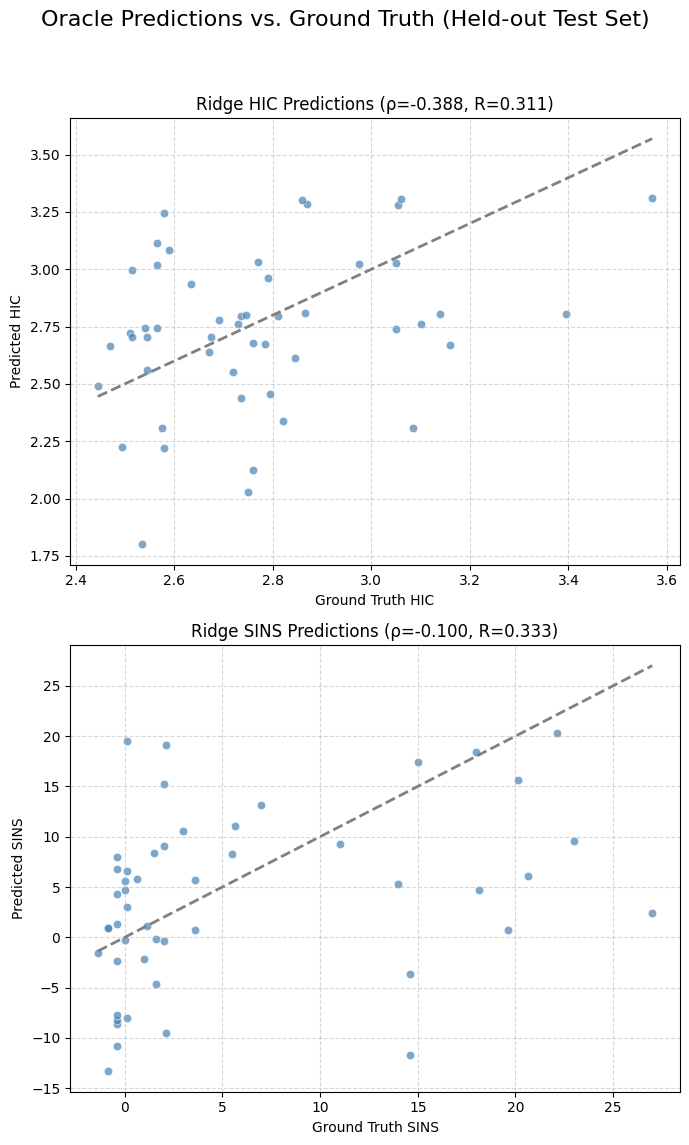

In [39]:
fig, axes = plt.subplots(2, 2 if USE_LORA_ORACLE else 1, figsize=(14 if USE_LORA_ORACLE else 7, 12))
fig.suptitle('Oracle Predictions vs. Ground Truth (Held-out Test Set)', fontsize=16)

# Ridge HIC
ax = axes[0, 0] if USE_LORA_ORACLE else axes[0]
sns.scatterplot(x=y_hic_test, y=pred_hic, ax=ax, alpha=0.7, color='steelblue')
ax.plot([y_hic_test.min(), y_hic_test.max()], [y_hic_test.min(), y_hic_test.max()],
        '--', color='gray', lw=2)
ax.set_title(f'Ridge HIC Predictions (ρ={rho_h:.3f}, R={r_h:.3f})')
ax.set_xlabel('Ground Truth HIC')
ax.set_ylabel('Predicted HIC')
ax.grid(True, linestyle='--', alpha=0.5)

if USE_LORA_ORACLE:
    # LoRA HIC
    ax = axes[0, 1]
    sns.scatterplot(x=lora_true_hic, y=lora_pred_hic, ax=ax, alpha=0.7, color='coral')
    ax.plot([lora_true_hic.min(), lora_true_hic.max()], [lora_true_hic.min(), lora_true_hic.max()],
            '--', color='gray', lw=2)
    ax.set_title(f'LoRA HIC Predictions (ρ={rho_h_lora:.3f}, R={r_h_lora:.3f})')
    ax.set_xlabel('Ground Truth HIC')
    ax.set_ylabel('Predicted HIC')
    ax.grid(True, linestyle='--', alpha=0.5)

# Ridge SINS
ax = axes[1, 0] if USE_LORA_ORACLE else axes[1]
sns.scatterplot(x=y_sins_test, y=pred_sins, ax=ax, alpha=0.7, color='steelblue')
ax.plot([y_sins_test.min(), y_sins_test.max()], [y_sins_test.min(), y_sins_test.max()],
        '--', color='gray', lw=2)
ax.set_title(f'Ridge SINS Predictions (ρ={rho_s:.3f}, R={r_s:.3f})')
ax.set_xlabel('Ground Truth SINS')
ax.set_ylabel('Predicted SINS')
ax.grid(True, linestyle='--', alpha=0.5)

if USE_LORA_ORACLE:
    # LoRA SINS
    ax = axes[1, 1]
    sns.scatterplot(x=lora_true_sins, y=lora_pred_sins, ax=ax, alpha=0.7, color='coral')
    ax.plot([lora_true_sins.min(), lora_true_sins.max()], [lora_true_sins.min(), lora_true_sins.max()],
            '--', color='gray', lw=2)
    ax.set_title(f'LoRA SINS Predictions (ρ={rho_s_lora:.3f}, R={r_s_lora:.3f})')
    ax.set_xlabel('Ground Truth SINS')
    ax.set_ylabel('Predicted SINS')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(CACHE('oracle_prediction_comparison.png'), dpi=150)
plt.show()


### Summary of Oracle Performance

In [40]:
print(f'\nOverall Oracle Performance Comparison (Held-out Test Set):')
print(f'{"Oracle Type":<15} {"Metric":<10} {"HIC":<10} {"SINS":<10}')
print(f'{"-"*15:<15} {"-"*10:<10} {"-"*10:<10} {"-"*10:<10}')
print(f'{"Ridge":<15} {"Spearman ρ":<10} {rho_h:<10.3f} {rho_s:<10.3f}')
print(f'{"":<15} {"Pearson R":<10} {r_h:<10.3f} {r_s:<10.3f}')
if USE_LORA_ORACLE:
    print(f'{"LoRA":<15} {"Spearman ρ":<10} {rho_h_lora:<10.3f} {rho_s_lora:<10.3f}')
    print(f'{"":<15} {"Pearson R":<10} {r_h_lora:<10.3f} {r_s_lora:<10.3f}')



Overall Oracle Performance Comparison (Held-out Test Set):
Oracle Type     Metric     HIC        SINS      
--------------- ---------- ---------- ----------
Ridge           Spearman ρ -0.388     -0.100    
                Pearson R  0.311      0.333     


---
## Section 10 — Save Artifacts for Evaluation Notebook

In [ ]:
# Save everything the evaluation notebook needs to run independently.
# The evaluation notebook reloads these files so it never has to re-run
# the expensive embedding extraction or model training steps.

# DataFrames
compare_df.to_csv(f'{EVAL_DIR}/compare_df.csv', index=False)
seq_df.to_csv(f'{EVAL_DIR}/seq_df.csv', index=False)
print('Saved: compare_df.csv, seq_df.csv')

# Original dataframe (sequences + metadata)
df[['antibody_name','vh_protein_sequence','vl_protein_sequence',
    'hcdr3_sequence','hcdr3_len','hierarchical_cluster_fold',
    'liability_count','HIC','AC-SINS_pH7.4'
    ]].to_csv(f'{EVAL_DIR}/df_sequences.csv', index=False)

# CDR3 index lists — saved as JSON because lists of lists don't fit in CSV
cdr3_idx_dict = {int(i): df['h_cdr3_idx'].iloc[i]
                 for i in range(len(df))
                 if isinstance(df['h_cdr3_idx'].iloc[i], list)}
with open(f'{EVAL_DIR}/cdr3_idx.json', 'w') as f:
    json.dump(cdr3_idx_dict, f)
print('Saved: df_sequences.csv, cdr3_idx.json')

# Oracle models and scalers
joblib.dump(oracle_hic,   f'{EVAL_DIR}/oracle_hic.pkl')
joblib.dump(oracle_sins,  f'{EVAL_DIR}/oracle_sins.pkl')
joblib.dump(full_scaler,  f'{EVAL_DIR}/full_scaler.pkl')
joblib.dump(cdr3_scaler,  f'{EVAL_DIR}/cdr3_scaler.pkl')
joblib.dump(fw_scaler,    f'{EVAL_DIR}/fw_scaler.pkl')
joblib.dump(pls,          f'{EVAL_DIR}/pls_model.pkl')
joblib.dump(pls_scaler,   f'{EVAL_DIR}/pls_scaler.pkl')
joblib.dump(dev_scaler,   f'{EVAL_DIR}/dev_scaler.pkl')
print('Saved: oracle models + scalers')

if USE_LORA_ORACLE and os.path.exists(LORA_CKPT_PATH):
    # Save LoRA checkpoint (already exists, but copy to eval_inputs for convenience)
    import shutil
    shutil.copy(LORA_CKPT_PATH, f'{EVAL_DIR}/lora_oracle_gdpa1.pt')

    # Save LoRA configuration for evaluation notebook
    lora_config = {
        'lora_r': LORA_R,
        'lora_alpha': LORA_ALPHA,
        'lora_dropout': LORA_DROPOUT,
        'hidden_size': LORA_HIDDEN_SIZE,
        'target_modules': AbLang2LoRAEncoder.LORA_TARGET_MODULES,
    }
    with open(f'{EVAL_DIR}/lora_config.json', 'w') as f:
        json.dump(lora_config, f)

    print('Saved: LoRA oracle checkpoint + config')

# PCA objects (for embedding space plots)
joblib.dump(pca,      f'{EVAL_DIR}/pca_cdr3.pkl')
full_pca = PCA(n_components=20, random_state=42).fit(X_full_tr)
joblib.dump(full_pca, f'{EVAL_DIR}/pca_full.pkl')
print('Saved: pca_cdr3.pkl, pca_full.pkl')

# Oracle training targets (needed for z-scoring composite score)
np.save(f'{EVAL_DIR}/y_hic_train.npy',  y_hic_train)
np.save(f'{EVAL_DIR}/y_sins_train.npy', y_sins_train)
np.save(f'{EVAL_DIR}/y_hic_test.npy',   y_hic_test)
np.save(f'{EVAL_DIR}/y_sins_test.npy',  y_sins_test)

# Split indices
np.save(f'{EVAL_DIR}/train_idx.npy', train_idx)
np.save(f'{EVAL_DIR}/test_idx.npy',  test_idx)

# Scaled embeddings (so eval notebook avoids re-embedding)
np.save(f'{EVAL_DIR}/X_cdr3_tr.npy', X_cdr3_tr)
np.save(f'{EVAL_DIR}/X_cdr3_te.npy', X_cdr3_te)
np.save(f'{EVAL_DIR}/X_fw_te.npy',   X_fw_te)
np.save(f'{EVAL_DIR}/X_full_tr.npy', X_full_tr)
np.save(f'{EVAL_DIR}/X_full_te.npy', X_full_te)
np.save(f'{EVAL_DIR}/train_pc20.npy',
        pca.transform(cdr3_embs[train_idx])[:, :20])
print('Saved: embeddings and PCA projections')

# File inventory
print(f'\nAll artifacts saved to: {EVAL_DIR}')
for fname in sorted(os.listdir(EVAL_DIR)):
    size = os.path.getsize(f'{EVAL_DIR}/{fname}') / 1024
    print(f'  {fname:<38} {size:>8.1f} KB')